# Unicament mappers y ver los indices

## Librerás

In [2]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


## Datos

### Sacar tickers

In [3]:

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 504 tickers
First 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK.B']
Found 504 weights
First 10 weights: ['7.97%', '6.48%', '6.14%', '4.32%', '2.88%', '2.78%', '2.69%', '2.62%', '2.51%', '1.72%']
Tickers after replacement: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK-B']


### Info financiera

In [4]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

import os

# Verificar si el archivo ya existe
csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    # ✅ ARCHIVO EXISTE - Cargar datos existentes
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo guardado...")
    print("=" * 80)
    
    try:
        ticker_info_df = pd.read_csv(csv_filename, index_col=0)
        
        # Convertir DataFrame a diccionario para ticker_info_db
        ticker_info_db = ticker_info_df.to_dict('index')
        
        print(f"✅ Datos cargados exitosamente")
        print(f"   📊 Total de tickers: {len(ticker_info_df)}")
        print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
        print(f"\n💡 Para actualizar los datos, elimina el archivo '{csv_filename}' y vuelve a ejecutar esta celda")
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los datos nuevamente...")
        # Si hay error, forzar descarga
        os.remove(csv_filename) if os.path.exists(csv_filename) else None
        ticker_info_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar información
    print("⚠️  Archivo 'sp500_ticker_info_database.csv' no encontrado")
    print("🔍 Descargando información detallada de todos los tickers del S&P 500...")
    print("⏱️  Esto puede tardar varios minutos...")
    print("=" * 80)
    
    ticker_info_db = {}
    failed_tickers = []
    
    for idx, ticker in enumerate(tickers, 1):
        try:
            # Mostrar progreso cada 50 tickers
            if idx % 50 == 0 or idx == 1:
                print(f"   Procesando ticker {idx}/{len(tickers)}: {ticker}")
            
            stock = yf.Ticker(ticker)
            info = stock.info
            
            # Extraer información relevante
            ticker_info_db[ticker] = {
                # Información básica
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'market_cap': info.get('marketCap', None),
                'country': info.get('country', 'Unknown'),
                'full_name': info.get('longName', ticker),
                
                # Métricas de valoración
                'pe_ratio': info.get('trailingPE', None),
                'forward_pe': info.get('forwardPE', None),
                'peg_ratio': info.get('pegRatio', None),
                'price_to_book': info.get('priceToBook', None),
                'price_to_sales': info.get('priceToSalesTrailing12Months', None),
                'enterprise_value': info.get('enterpriseValue', None),
                'ev_to_ebitda': info.get('enterpriseToEbitda', None),
                
                # Dividendos
                'dividend_yield': info.get('dividendYield', None),
                'dividend_rate': info.get('dividendRate', None),
                'payout_ratio': info.get('payoutRatio', None),
                'five_year_avg_dividend_yield': info.get('fiveYearAvgDividendYield', None),
                
                # Rentabilidad
                'profit_margins': info.get('profitMargins', None),
                'operating_margins': info.get('operatingMargins', None),
                'gross_margins': info.get('grossMargins', None),
                'roe': info.get('returnOnEquity', None),
                'roa': info.get('returnOnAssets', None),
                
                # Crecimiento
                'revenue_growth': info.get('revenueGrowth', None),
                'earnings_growth': info.get('earningsGrowth', None),
                'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
                
                # Riesgo y volatilidad
                'beta': info.get('beta', None),
                '52week_high': info.get('fiftyTwoWeekHigh', None),
                '52week_low': info.get('fiftyTwoWeekLow', None),
                '52week_change': info.get('52WeekChange', None),
                
                # Liquidez y deuda
                'current_ratio': info.get('currentRatio', None),
                'quick_ratio': info.get('quickRatio', None),
                'debt_to_equity': info.get('debtToEquity', None),
                'total_debt': info.get('totalDebt', None),
                'total_cash': info.get('totalCash', None),
                
                # Analistas y recomendaciones
                'recommendation': info.get('recommendationKey', 'Unknown'),
                'recommendation_mean': info.get('recommendationMean', None),
                'target_mean_price': info.get('targetMeanPrice', None),
                'target_high_price': info.get('targetHighPrice', None),
                'target_low_price': info.get('targetLowPrice', None),
                'number_of_analysts': info.get('numberOfAnalystOpinions', None),
                
                # Información adicional
                'employees': info.get('fullTimeEmployees', None),
                'exchange': info.get('exchange', 'Unknown'),
                'quote_type': info.get('quoteType', 'Unknown'),
            }
            
        except Exception as e:
            failed_tickers.append(ticker)
            ticker_info_db[ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown',
                'error': str(e)
            }
    
    print(f"\n{'='*80}")
    print(f"📊 RESUMEN DE DESCARGA:")
    print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
    if failed_tickers:
        print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
    
    # Crear DataFrame para análisis fácil
    ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')
    
    print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")
    
    # Guardar en CSV para uso posterior
    ticker_info_df.to_csv(csv_filename)
    print(f"   💾 Base de datos guardada en '{csv_filename}'")

# Mostrar primeras filas (común para ambos casos)
print(f"\n{'='*80}")
print("📋 Primeras filas de la base de datos:")
display(ticker_info_df.head(10))

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo guardado...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 43

💡 Para actualizar los datos, elimina el archivo 'sp500_ticker_info_database.csv' y vuelve a ejecutar esta celda

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name,pe_ratio,forward_pe,peg_ratio,price_to_book,price_to_sales,...,recommendation,recommendation_mean,target_mean_price,target_high_price,target_low_price,number_of_analysts,employees,exchange,quote_type,error
NVDA,Technology,Semiconductors,5.105445e+12,United States,NVIDIA Corporation,59.912860,50.896847,NaN,50.983470,30.900524,...,strong_buy,1.34375,229.32070,350.00,100.0,57.0,36000.0,NMS,EQUITY,NaN
AAPL,Technology,Consumer Electronics,3.961836e+12,United States,Apple Inc.,35.941017,32.264740,NaN,53.720695,9.519959,...,buy,2.00000,278.01633,345.00,200.0,41.0,166000.0,NMS,EQUITY,NaN
MSFT,Technology,Software - Infrastructure,3.842837e+12,United States,Microsoft Corporation,36.721590,34.584614,NaN,10.586404,13.079236,...,strong_buy,1.21053,626.26500,730.00,483.0,52.0,228000.0,NMS,EQUITY,NaN
AMZN,Consumer Cyclical,Internet Retail,2.734878e+12,United States,"Amazon.com, Inc.",36.134182,41.598373,NaN,7.396709,3.955811,...,strong_buy,1.29851,288.83392,351.87,240.0,61.0,1578000.0,NMS,EQUITY,NaN
GOOGL,Communication Services,Internet Content & Information,3.412471e+12,United States,Alphabet Inc.,27.916010,31.530134,NaN,8.819343,8.852615,...,strong_buy,1.48485,310.16370,360.00,185.0,54.0,190167.0,NMS,EQUITY,NaN
AVGO,Technology,Semiconductors,1.721774e+12,United States,Broadcom Inc.,93.010200,59.092384,NaN,6.156600,28.731674,...,strong_buy,1.28261,392.38165,475.00,273.4,41.0,37000.0,NMS,EQUITY,NaN
GOOG,Communication Services,Internet Content & Information,3.410808e+12,United States,Alphabet Inc.,27.964922,31.620672,NaN,8.834795,8.848301,...,strong_buy,1.49254,298.42776,345.00,185.0,18.0,190167.0,NMS,EQUITY,NaN
META,Communication Services,Internet Content & Information,1.621682e+12,United States,"Meta Platforms, Inc.",28.430845,25.430435,NaN,8.357885,8.559387,...,strong_buy,1.47059,844.74884,1117.00,560.0,60.0,78450.0,NMS,EQUITY,NaN
TSLA,Consumer Cyclical,Auto Manufacturers,1.556932e+12,United States,"Tesla, Inc.",320.640400,144.486110,NaN,19.458600,16.279493,...,hold,2.61702,392.04977,600.00,120.0,41.0,125665.0,NMS,EQUITY,NaN
BRK-B,Financial Services,Insurance - Diversified,1.029713e+12,United States,Berkshire Hathaway Inc.,16.362062,23.777142,NaN,0.001028,2.781873,...,buy,1.75000,528.00000,595.00,479.0,3.0,392400.0,NYQ,EQUITY,NaN


### Histricos

In [30]:



START_DATE='2015-01-01'
END_DATE='2025-11-01'
AN_DATE='2024-01-01'

In [31]:
# -----------------------------
# -----------------------------
# Descargar precios históricos
# -----------------------------
all_tickers_data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
all_tickers_data = all_tickers_data.dropna(axis=1)  # eliminar columnas con datos faltantes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

[*********************100%***********************]  504 of 504 completed

1 Failed download:
[*********************100%***********************]  504 of 504 completed

1 Failed download:
[*********************100%***********************]  504 of 504 completed

1 Failed download:
['KVUE']: Timeout('Failed to perform, curl: (28) Operation timed out after 10000 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['KVUE']: Timeout('Failed to perform, curl: (28) Operation timed out after 10000 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['KVUE']: Timeout('Failed to perform, curl: (28) Operation timed out after 10000 milliseconds with 0 bytes received. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


✅ Datos descargados:
   📊 Total: (2725, 464) (desde 2015-01-01 hasta 2025-11-01)
   📊 Período de análisis: (2264, 464) (desde 2015-01-01 hasta 2024-01-01)
   📊 Período de validación: (461, 464) (desde 2024-01-01 hasta 2025-11-01)


In [32]:
## Datos S&P500
# Descargar SPY para benchmark
SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Verificar si es Serie o DataFrame y convertir apropiadamente
if isinstance(SPY_data, pd.Series):
    SPY = SPY_data.to_frame(name='SPY')
else:
    # Si ya es DataFrame, asegurarse que la columna se llame 'SPY'
    SPY = SPY_data.to_frame() if len(SPY_data.shape) == 1 else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY descargado:")
print(f"   📊 SPY_analysis: {SPY_analysis.shape}")
print(f"   📊 SPY_validation: {SPY_validation.shape}")
print(f"   📋 Columnas: {SPY_analysis.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

✅ SPY descargado:
   📊 SPY_analysis: (2264, 1)
   📊 SPY_validation: (461, 1)
   📋 Columnas: ['SPY']


In [33]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 464 tickers, 9 métricas
📊 Datos preparados: 464 tickers, 9 métricas
📊 Datos preparados: 464 tickers, 9 métricas


# Modelos de mapper

In [34]:
# =======================================================
# CREAR SUBCARPETA PARA VISUALIZACIONES
# =======================================================

import os

# Crear la subcarpeta para todas las visualizaciones
output_folder = 'Mappers_experimentacion'
os.makedirs(output_folder, exist_ok=True)
print(f"📁 Subcarpeta creada: {output_folder}/")
print(f"🌐 Todas las visualizaciones HTML se guardarán en esta carpeta")

📁 Subcarpeta creada: Mappers_experimentacion/
🌐 Todas las visualizaciones HTML se guardarán en esta carpeta


## Modelo 1

In [35]:
# =======================================================
# 📈 MAPPER ENFOCADO EN TENDENCIA DE CRECIMIENTO
# =======================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import kmapper as km

# ==========================================
# 1. CALCULAR FEATURES DE TENDENCIA
# ==========================================

def calcular_features_tendencia(prices_df):
    """
    Calcula features enfocadas en la tendencia de crecimiento porcentual.
    
    Returns:
    --------
    features_matrix : array
        Matriz de features (n_tickers x n_features)
    """
    
    features_list = []
    
    for ticker in prices_df.columns:
        serie = prices_df[ticker].dropna()
        
        if len(serie) < 10:
            # Si no hay suficientes datos, llenar con ceros
            features_list.append(np.zeros(8))
            continue
        
        # 1. RETORNOS PORCENTUALES DIARIOS
        daily_returns = serie.pct_change().dropna()
        
        # 2. TENDENCIA LINEAL (pendiente normalizada)
        x = np.arange(len(serie))
        y = serie.values
        coefficients = np.polyfit(x, y, 1)
        trend_slope = coefficients[0] / serie.iloc[0]  # Normalizado
        
        # 3. ACELERACIÓN (segunda derivada - tendencia de la tendencia)
        # Dividir serie en 2 mitades y comparar pendientes
        mid = len(serie) // 2
        x1, y1 = np.arange(mid), serie.iloc[:mid].values
        x2, y2 = np.arange(len(serie) - mid), serie.iloc[mid:].values
        
        slope1 = np.polyfit(x1, y1, 1)[0] / serie.iloc[0]
        slope2 = np.polyfit(x2, y2, 1)[0] / serie.iloc[mid]
        acceleration = slope2 - slope1  # Aceleración
        
        # 4. MOMENTUM (retorno reciente vs retorno total)
        recent_return = (serie.iloc[-5:].mean() / serie.iloc[-10:-5].mean()) - 1
        total_return = (serie.iloc[-1] / serie.iloc[0]) - 1
        momentum_ratio = recent_return / total_return if total_return != 0 else 0
        
        # 5. CONSISTENCIA DE CRECIMIENTO (% de días positivos)
        pct_positive_days = (daily_returns > 0).sum() / len(daily_returns)
        
        # 6. VOLATILIDAD DE RETORNOS (menor es mejor para predicción)
        volatility = daily_returns.std()
        
        # 7. RETORNO MEDIO DIARIO
        mean_daily_return = daily_returns.mean()
        
        # 8. R² DE LA TENDENCIA (calidad del ajuste lineal)
        y_pred = coefficients[0] * x + coefficients[1]
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        # Crear vector de features
        features = np.array([
            trend_slope,           # Peso alto: tendencia principal
            acceleration,          # Peso alto: ¿está acelerando?
            momentum_ratio,        # Peso medio: momentum reciente
            pct_positive_days,     # Peso medio: consistencia
            mean_daily_return,     # Peso medio: retorno promedio
            r_squared,             # Peso bajo: calidad del ajuste
            -volatility,           # Peso bajo: negativo porque menor es mejor
            total_return           # Peso bajo: retorno total
        ])
        
        features_list.append(features)
    
    return np.array(features_list)

# Calcular features enfocadas en tendencia
print("🔍 Calculando features de tendencia de crecimiento...")
features_tendencia = calcular_features_tendencia(tickers_data)

print(f"✅ Features calculadas: {features_tendencia.shape}")
print(f"   Tickers: {features_tendencia.shape[0]}")
print(f"   Features por ticker: {features_tendencia.shape[1]}")
print(f"\n📊 Features utilizadas:")
print(f"   1. Tendencia lineal (slope normalizado)")
print(f"   2. Aceleración (segunda derivada)")
print(f"   3. Momentum ratio (reciente vs total)")
print(f"   4. % días positivos")
print(f"   5. Retorno medio diario")
print(f"   6. R² de tendencia")
print(f"   7. Volatilidad (negativa)")
print(f"   8. Retorno total")

# ==========================================
# 2. ESCALADO Y MAPPER
# ==========================================

# Escalar features (importante para dar pesos equitativos)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features_tendencia)

print(f"\n✅ Features escaladas: {data_scaled.shape}")

# Inicializar Mapper
mapper = km.KeplerMapper(verbose=1)

# Proyección (lens): PCA a 2D enfocado en las features de tendencia
lens = mapper.fit_transform(data_scaled, projection=PCA(n_components=2))

print(f"\n✅ Proyección PCA completada: {lens.shape}")

# Construcción del grafo con KMeans
# Ajustar n_clusters basado en cuántos grupos de tendencia esperamos
graph_tendencia = mapper.map(
    lens, 
    data_scaled, 
    clusterer=KMeans(n_clusters=4, random_state=42),  # 4 clusters: alto/medio/bajo/negativo
    cover=km.Cover(n_cubes=12, perc_overlap=0.6)  # Más resolución
)

print(f"\n✅ Grafo de Mapper construido:")
print(f"   Nodos encontrados: {len(graph_tendencia['nodes'])}")
print(f"   Aristas encontradas: {len(graph_tendencia['links'])}")

# ==========================================
# 3. COLOREAR POR TENDENCIA DE CRECIMIENTO
# ==========================================

# Calcular tendencia promedio por ticker para colorear
tendencias_tickers = features_tendencia[:, 0]  # Primera columna = trend_slope

print(f"\n📊 Estadísticas de tendencia:")
print(f"   Máxima: {tendencias_tickers.max():.6f}")
print(f"   Promedio: {tendencias_tickers.mean():.6f}")
print(f"   Mínima: {tendencias_tickers.min():.6f}")

# Visualización interactiva coloreada por tendencia
mapper.visualize(
    graph_tendencia, 
    title="🚀 Mapper: Agrupación por Probabilidad de Crecimiento Porcentual",
    custom_tooltips=np.array(ticker_names),
    color_values=tendencias_tickers,  # ✅ Colorear por tendencia
    color_function_name='Tendencia de Crecimiento',
    path_html="Mappers_experimentacion/mapper_tendencia_crecimiento.html"
)

print(f"\n✅ Visualización guardada en: Mappers_experimentacion/mapper_tendencia_crecimiento.html")

# ==========================================
# 4. ANÁLISIS DE CLUSTERS POR TENDENCIA
# ==========================================

print("\n" + "="*80)
print("📊 ANÁLISIS DE CLUSTERS POR TENDENCIA DE CRECIMIENTO")
print("="*80)

# Extraer clusters del grafo
cluster_assignments = {}
for node_id, node_members in graph_tendencia['nodes'].items():
    for member_idx in node_members:
        if member_idx not in cluster_assignments:
            cluster_assignments[member_idx] = []
        cluster_assignments[member_idx].append(node_id)

# Agrupar por nodos
nodos_info = []
for node_id, members in graph_tendencia['nodes'].items():
    if len(members) == 0:
        continue
    
    # Calcular tendencia promedio del nodo
    tendencias_nodo = [tendencias_tickers[idx] for idx in members]
    tendencia_promedio = np.mean(tendencias_nodo)
    
    # Obtener nombres de tickers
    tickers_nodo = [ticker_names[idx] for idx in members]
    
    nodos_info.append({
        'node_id': node_id,
        'n_tickers': len(members),
        'tendencia_promedio': tendencia_promedio,
        'tickers': tickers_nodo[:5]  # Mostrar solo primeros 5
    })

# Ordenar por tendencia (de mayor a menor)
nodos_info_sorted = sorted(nodos_info, key=lambda x: x['tendencia_promedio'], reverse=True)

print(f"\n🔝 TOP 5 NODOS CON MAYOR TENDENCIA DE CRECIMIENTO:")
print("="*80)
for i, nodo in enumerate(nodos_info_sorted[:5], 1):
    print(f"\n{i}. Nodo {nodo['node_id']}:")
    print(f"   Tendencia promedio: {nodo['tendencia_promedio']:.6f}")
    print(f"   Tickers en el nodo: {nodo['n_tickers']}")
    print(f"   Ejemplos: {', '.join(nodo['tickers'])}")

print(f"\n\n📉 TOP 5 NODOS CON MENOR TENDENCIA (o negativa):")
print("="*80)
for i, nodo in enumerate(nodos_info_sorted[-5:], 1):
    print(f"\n{i}. Nodo {nodo['node_id']}:")
    print(f"   Tendencia promedio: {nodo['tendencia_promedio']:.6f}")
    print(f"   Tickers en el nodo: {nodo['n_tickers']}")
    print(f"   Ejemplos: {', '.join(nodo['tickers'])}")

🔍 Calculando features de tendencia de crecimiento...
✅ Features calculadas: (464, 8)
   Tickers: 464
   Features por ticker: 8

📊 Features utilizadas:
   1. Tendencia lineal (slope normalizado)
   2. Aceleración (segunda derivada)
   3. Momentum ratio (reciente vs total)
   4. % días positivos
   5. Retorno medio diario
   6. R² de tendencia
   7. Volatilidad (negativa)
   8. Retorno total

✅ Features escaladas: (464, 8)
KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (464, 8)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()


✅ Proyección PCA completada: (464, 2)
Mapping on data shaped (464, 8) using lens shaped (464, 2)

Creating 144 hypercubes.

Created 999 edges and 128 nodes in 0:00:00.127010.

✅ Grafo de Mapper construido:
   Nodos encontrados: 128
   Aristas encontradas: 112

📊 Estadísticas de tendencia:
   Máxima: 

## Modelo 2

In [49]:
print("="*90)
print("🎯 MODELO MAPPER 3: DIVERSIFICACIÓN CON TENDENCIA DE CRECIMIENTO".center(90))
print("="*90)
print("\n💡 ESTRATEGIA:")
print("   1. Filtrar solo tickers con tendencia de crecimiento positiva")
print("   2. Agrupar tickers DIFERENTES entre sí (anti-correlación)")
print("   3. Objetivo: Reducir volatilidad con diversificación manteniendo tendencia alcista")
print("   4. Preferir pocos clusters de alta calidad")
print("="*90)

# ==========================================
# 1. FILTRADO INICIAL: SOLO TICKERS CON TENDENCIA POSITIVA
# ==========================================

print("\n🔍 PASO 1: Filtrado de tickers con tendencia de crecimiento...")

# Calcular tendencia lineal para cada ticker
def calcular_tendencia_y_correlacion(tickers_data):
    """
    Calcula tendencia y matriz de correlación para clustering por diversificación.
    """
    tendencias = []
    precios_normalizados = []
    ticker_list = []
    
    for ticker in tickers_data.columns:
        prices = tickers_data[ticker].dropna()
        
        if len(prices) < 100:  # Mínimo de datos
            continue
        
        # Normalizar precios (importante para correlación)
        prices_norm = (prices - prices.mean()) / prices.std()
        
        # Calcular tendencia lineal
        x = np.arange(len(prices))
        coeffs = np.polyfit(x, prices.values, 1)
        trend_slope = coeffs[0]
        
        # Calcular retorno total
        total_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
        
        tendencias.append({
            'ticker': ticker,
            'trend_slope': trend_slope,
            'total_return': total_return,
            'prices': prices.values
        })
        
        precios_normalizados.append(prices_norm.values)
        ticker_list.append(ticker)
    
    return tendencias, precios_normalizados, ticker_list

tendencias_info, precios_norm, tickers_filtrados = calcular_tendencia_y_correlacion(tickers_data)

# Filtrar solo tickers con tendencia positiva
tickers_positivos = [t for t in tendencias_info if t['trend_slope'] > 0 and t['total_return'] > 0]

print(f"\n📊 Resultados del filtrado:")
print(f"   Total de tickers analizados: {len(tendencias_info)}")
print(f"   Tickers con tendencia POSITIVA: {len(tickers_positivos)}")
print(f"   Tickers filtrados: {len(tendencias_info) - len(tickers_positivos)}")
print(f"   Tasa de aprobación: {len(tickers_positivos)/len(tendencias_info)*100:.1f}%")

# Ordenar por tendencia
tickers_positivos_sorted = sorted(tickers_positivos, key=lambda x: x['trend_slope'], reverse=True)

print(f"\n🔝 Top 10 tickers con MEJOR tendencia:")
for i, t in enumerate(tickers_positivos_sorted[:10], 1):
    print(f"   {i:2d}. {t['ticker']:6s} - Tendencia: {t['trend_slope']:>10.6f}, Retorno: {t['total_return']:>7.2f}%")

# ==========================================
# 2. MATRIZ DE CORRELACIÓN PARA DIVERSIFICACIÓN
# ==========================================

print(f"\n🔍 PASO 2: Calculando matriz de correlación entre tickers positivos...")

# Obtener solo los precios de tickers con tendencia positiva
ticker_names_positivos = [t['ticker'] for t in tickers_positivos]
prices_matrix = []

for ticker_info in tickers_positivos:
    ticker = ticker_info['ticker']
    prices = tickers_data[ticker].dropna()
    
    # Normalizar para correlación justa
    prices_norm = (prices - prices.mean()) / prices.std()
    prices_matrix.append(prices_norm.values)

# Ajustar longitud (usar mínimo común)
min_length = min(len(p) for p in prices_matrix)
prices_matrix_aligned = np.array([p[-min_length:] for p in prices_matrix])

# Calcular matriz de correlación
correlation_matrix = np.corrcoef(prices_matrix_aligned)

print(f"\n✅ Matriz de correlación calculada: {correlation_matrix.shape}")
print(f"   Correlación promedio: {np.mean(correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]):.4f}")
print(f"   Correlación máxima: {np.max(correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]):.4f}")
print(f"   Correlación mínima: {np.min(correlation_matrix[np.triu_indices_from(correlation_matrix, k=1)]):.4f}")

# ==========================================
# 3. FEATURES PARA CLUSTERING: DIVERSIFICACIÓN
# ==========================================

print(f"\n🔍 PASO 3: Creando features para clustering por diversificación...")

def calcular_features_diversificacion(tickers_positivos, correlation_matrix, tickers_data):
    """
    Crea features que favorecen la diversificación:
    - Anti-correlación promedio con otros tickers
    - Tendencia de crecimiento
    - Ratio retorno/volatilidad
    """
    features_list = []
    
    for i, ticker_info in enumerate(tickers_positivos):
        ticker = ticker_info['ticker']
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # 1. Anti-correlación promedio (invertida para clustering)
        # Queremos AGRUPAR tickers con BAJA correlación entre sí
        avg_correlation = np.mean(correlation_matrix[i, :])
        anti_correlation = 1 - avg_correlation  # Mayor valor = menor correlación
        
        # 2. Desviación estándar de correlaciones (diversidad en comportamiento)
        std_correlation = np.std(correlation_matrix[i, :])
        
        # 3. Tendencia de crecimiento (ya sabemos que es positiva)
        trend_slope = ticker_info['trend_slope']
        
        # 4. Volatilidad (queremos diversificarla)
        volatility = returns.std() * np.sqrt(252) * 100
        
        # 5. Sharpe ratio simple
        avg_return = returns.mean() * 252 * 100
        sharpe = avg_return / volatility if volatility > 0 else 0
        
        # 6. Retorno total
        total_return = ticker_info['total_return']
        
        # Features ponderadas para clustering
        features = np.array([
            anti_correlation * 3,      # 🔥 PESO ALTO: Queremos diversificación
            std_correlation * 2,       # PESO MEDIO: Variedad en comportamiento
            trend_slope * 2,           # PESO MEDIO: Mantener tendencia positiva
            sharpe * 1.5,              # PESO MEDIO: Calidad del retorno
            total_return / 100,        # PESO BAJO: Normalizado
            -volatility / 100          # PESO BAJO: Negativo (menor es mejor)
        ])
        
        features_list.append(features)
    
    return np.array(features_list)

features_diversificacion = calcular_features_diversificacion(
    tickers_positivos, 
    correlation_matrix,
    tickers_data
)

print(f"✅ Features de diversificación calculadas: {features_diversificacion.shape}")
print(f"\n📊 Features utilizadas (en orden de importancia):")
print(f"   1. 🔥 Anti-correlación promedio (peso x3) - Favorece diversificación")
print(f"   2. Desv. estándar de correlaciones (peso x2) - Variedad de comportamiento")
print(f"   3. Tendencia de crecimiento (peso x2) - Mantiene foco en crecimiento")
print(f"   4. Sharpe Ratio (peso x1.5) - Calidad del retorno")
print(f"   5. Retorno total normalizado (peso x1)")
print(f"   6. Volatilidad negativa normalizada (peso x1) - Menor es mejor")

# ==========================================
# 4. CLUSTERING CON MAPPER
# ==========================================

print(f"\n🔍 PASO 4: Construyendo Mapper con enfoque en diversificación...")

# Escalar features
scaler_div = StandardScaler()
data_scaled_div = scaler_div.fit_transform(features_diversificacion)

# Inicializar Mapper
mapper_div = km.KeplerMapper(verbose=1)

# Proyección: PCA a 2D
lens_div = mapper_div.fit_transform(data_scaled_div, projection=PCA(n_components=2))

print(f"\n✅ Proyección PCA completada: {lens_div.shape}")

# Construcción del grafo
# Usamos MENOS clusters en KMeans para obtener grupos más diversos
graph_diversificacion = mapper_div.map(
    lens_div, 
    data_scaled_div, 
    clusterer=KMeans(n_clusters=3, random_state=42),  # ✅ Solo 3 clusters: alta/media/baja diversificación
    cover=km.Cover(n_cubes=8, perc_overlap=0.5)  # ✅ Menos cubos = menos clusters finales
)

print(f"\n✅ Grafo de Mapper construido:")
print(f"   Nodos encontrados: {len(graph_diversificacion['nodes'])}")
print(f"   Aristas encontradas: {len(graph_diversificacion['links'])}")

# ==========================================
# 5. COLOREAR POR ANTI-CORRELACIÓN
# ==========================================

# Usar anti-correlación para colorear (primera feature)
anti_correlations = features_diversificacion[:, 0]

print(f"\n📊 Estadísticas de anti-correlación:")
print(f"   Máxima (más diverso): {anti_correlations.max():.4f}")
print(f"   Promedio: {anti_correlations.mean():.4f}")
print(f"   Mínima (menos diverso): {anti_correlations.min():.4f}")

# Visualización
mapper_div.visualize(
    graph_diversificacion, 
    title="🎯 Mapper: Diversificación con Tendencia de Crecimiento",
    custom_tooltips=np.array(ticker_names_positivos),
    color_values=anti_correlations,
    color_function_name='Potencial de Diversificación',
    path_html="Mappers_experimentacion/mapper_diversificacion_crecimiento.html"
)

print(f"\n✅ Visualización guardada en: Mappers_experimentacion/mapper_diversificacion_crecimiento.html")

# ==========================================
# 6. ANÁLISIS DE CLUSTERS RESULTANTES
# ==========================================

print("\n" + "="*90)
print("📊 ANÁLISIS DE CLUSTERS: DIVERSIFICACIÓN + CRECIMIENTO")
print("="*90)

# Extraer información de clusters
nodos_diversificacion = []

for node_id, members in graph_diversificacion['nodes'].items():
    if len(members) < 3:  # ✅ Filtrar clusters muy pequeños
        continue
    
    # Tickers en el nodo
    tickers_nodo = [ticker_names_positivos[idx] for idx in members]
    
    # Métricas del nodo
    anti_corr_nodo = [anti_correlations[idx] for idx in members]
    tendencias_nodo = [tickers_positivos[idx]['trend_slope'] for idx in members]
    retornos_nodo = [tickers_positivos[idx]['total_return'] for idx in members]
    
    # Calcular correlación INTERNA del cluster
    indices_nodo = list(members)
    if len(indices_nodo) > 1:
        submatrix = correlation_matrix[np.ix_(indices_nodo, indices_nodo)]
        correlacion_interna = np.mean(submatrix[np.triu_indices_from(submatrix, k=1)])
    else:
        correlacion_interna = 1.0
    
    nodos_diversificacion.append({
        'node_id': node_id,
        'n_tickers': len(members),
        'tickers': tickers_nodo,
        'anti_correlacion_promedio': np.mean(anti_corr_nodo),
        'correlacion_interna': correlacion_interna,
        'tendencia_promedio': np.mean(tendencias_nodo),
        'retorno_promedio': np.mean(retornos_nodo),
        'diversificacion_score': np.mean(anti_corr_nodo) * (1 - correlacion_interna)
    })

# Ordenar por score de diversificación
nodos_diversificacion_sorted = sorted(nodos_diversificacion, 
                                     key=lambda x: x['diversificacion_score'], 
                                     reverse=True)

print(f"\n🎯 Total de clusters encontrados: {len(nodos_diversificacion_sorted)}")
print(f"\n{'='*90}")
print(f"🏆 CLUSTERS ORDENADOS POR POTENCIAL DE DIVERSIFICACIÓN:")
print(f"{'='*90}")

for i, nodo in enumerate(nodos_diversificacion_sorted, 1):
    print(f"\n{'─'*90}")
    print(f"Cluster #{i} - Nodo {nodo['node_id']}")
    print(f"{'─'*90}")
    print(f"   📊 Tamaño: {nodo['n_tickers']} tickers")
    print(f"   🎯 Score de Diversificación: {nodo['diversificacion_score']:.4f}")
    print(f"   🔄 Correlación interna: {nodo['correlacion_interna']:.4f} (menor = más diverso)")
    print(f"   📈 Tendencia promedio: {nodo['tendencia_promedio']:.6f}")
    print(f"   💰 Retorno promedio: {nodo['retorno_promedio']:.2f}%")
    print(f"   🎲 Anti-correlación promedio: {nodo['anti_correlacion_promedio']:.4f}")
    print(f"\n   📋 Tickers en el cluster:")
    
    # Mostrar tickers en filas de 10
    for j in range(0, len(nodo['tickers']), 10):
        tickers_row = nodo['tickers'][j:j+10]
        print(f"      {', '.join(tickers_row)}")

print(f"\n{'='*90}")
print(f"💡 INTERPRETACIÓN:")
print(f"{'='*90}")
print(f"✅ Correlación interna BAJA = Mayor diversificación dentro del cluster")
print(f"✅ Tendencia promedio POSITIVA = Todos tienen potencial de crecimiento")
print(f"✅ Score de diversificación ALTO = Mejor balance entre crecimiento y diversificación")
print(f"\n🎯 ESTRATEGIA RECOMENDADA:")
print(f"   Seleccionar los clusters con mayor 'Score de Diversificación'")
print(f"   Estos ofrecen el mejor balance entre:")
print(f"   • Tendencia de crecimiento positiva (todos los tickers crecen)")
print(f"   • Baja correlación interna (comportamientos diferentes)")
print(f"   • Reducción de volatilidad por diversificación")
print(f"{'='*90}\n")

# Guardar información para uso posterior
graph_diversificacion_info = {
    'graph': graph_diversificacion,
    'ticker_names': ticker_names_positivos,
    'nodos_info': nodos_diversificacion_sorted,
    'features': features_diversificacion
}

print("✅ Modelo 3 completado. Información guardada en 'graph_diversificacion_info'")

             🎯 MODELO MAPPER 3: DIVERSIFICACIÓN CON TENDENCIA DE CRECIMIENTO              

💡 ESTRATEGIA:
   1. Filtrar solo tickers con tendencia de crecimiento positiva
   2. Agrupar tickers DIFERENTES entre sí (anti-correlación)
   3. Objetivo: Reducir volatilidad con diversificación manteniendo tendencia alcista
   4. Preferir pocos clusters de alta calidad

🔍 PASO 1: Filtrado de tickers con tendencia de crecimiento...

📊 Resultados del filtrado:
   Total de tickers analizados: 464
   Tickers con tendencia POSITIVA: 428
   Tickers filtrados: 36
   Tasa de aprobación: 92.2%

🔝 Top 10 tickers con MEJOR tendencia:
    1. NVR    - Tendencia:   2.104085, Retorno:  459.15%
    2. AZO    - Tendencia:   0.903305, Retorno:  319.20%
    3. BKNG   - Tendencia:   0.605326, Retorno:  210.60%
    4. MTD    - Tendencia:   0.571092, Retorno:  301.71%
    5. FICO   - Tendencia:   0.321604, Retorno: 1515.74%
    6. NOW    - Tendencia:   0.278384, Retorno:  948.52%
    7. TDG    - Tendencia:   0.2746

## Extraer resultados

In [63]:
graphs={
    #'Historic1': graph_hist_1,
    'Historic2_tendencia': graph_tendencia,
    'Diversificacion_crecimiento': graph_diversificacion
    #'Sharpe': G,
    #'Volatilidad': G_vol,
    #'Retorno': G_ret,
    #'PCA': G_pca
    }


graph_names = list(graphs.keys())

categories = {ticker: ticker_info_db[ticker]['sector'] for ticker in ticker_names}
#market_caps = {ticker: ticker_info_db[ticker]['market_cap'] for ticker in ticker_names}
market_caps = {ticker: ticker_info_db.get(ticker, {}).get('market_cap', np.nan) for ticker in ticker_names}

In [64]:
missing_caps = [t for t in ticker_names if 'market_cap' not in ticker_info_db.get(t, {})]
if missing_caps:
    print("Missing market_cap for:", missing_caps)

In [65]:
"""
Analiza todos los clusters encontrados en los diferentes archivos Mapper
"""
print("📊 ANALIZANDO TODOS LOS CLUSTERS DEL MAPPER")
print("=" * 60)

# Diccionario para almacenar todos los clusters encontrados
def extract_clusters_from_all_graphs(graphs_dict, ticker_names, min_cluster_size=2):
    """
    Extrae clusters de todos los grafos en el diccionario graphs.
    
    Parámetros:
    -----------
    graphs_dict : dict
        Diccionario con {graph_label: graph_object}
    ticker_names : list
        Lista de nombres de tickers
    min_cluster_size : int
        Tamaño mínimo de cluster (default: 2)
    
    Retorna:
    --------
    all_clusters : dict
        Diccionario con todos los clusters encontrados
    """
    all_clusters = {}
    total_clusters = 0
    
    for graph_label, graph in graphs_dict.items():
        print(f"\n🔍 Extrayendo clusters del análisis por {graph_label}:")
        print(f"   Total de nodos: {len(graph['nodes'])}")
        
        clusters_in_graph = 0
        for i, (node_name, node_indices) in enumerate(graph['nodes'].items()):
            if len(node_indices) >= min_cluster_size:
                cluster_tickers = [ticker_names[idx] for idx in node_indices]
                cluster_name = f"{graph_label}_Cluster_{i+1}"
                all_clusters[cluster_name] = {
                    'tickers': cluster_tickers,
                    'type': graph_label,
                    'node_name': node_name,
                    'size': len(cluster_tickers)
                }
                print(f"     -{cluster_name}: {cluster_tickers} ({len(cluster_tickers)} tickers)")
                clusters_in_graph += 1
        
        print(f"   📌 {clusters_in_graph} clusters encontrados en {graph_label}")
        total_clusters += clusters_in_graph
    
    print(f"\n{'='*60}")
    print(f"📋 RESUMEN TOTAL: {total_clusters} clusters encontrados en {len(graphs_dict)} grafos")
    print(f"{'='*60}")
    
    return all_clusters


# Ejecutar la extracción para todos los grafos
all_clusters = extract_clusters_from_all_graphs(
    graphs_dict=graphs,
    ticker_names=ticker_names,
    min_cluster_size=4
)

📊 ANALIZANDO TODOS LOS CLUSTERS DEL MAPPER

🔍 Extrayendo clusters del análisis por Historic2_tendencia:
   Total de nodos: 128
     -Historic2_tendencia_Cluster_1: ['DVN', 'EQT', 'HAL', 'OXY'] (4 tickers)
     -Historic2_tendencia_Cluster_5: ['APA', 'DVN', 'EQT', 'FCX', 'OXY', 'TRGP'] (6 tickers)
     -Historic2_tendencia_Cluster_8: ['BIIB', 'BKR', 'EOG', 'EXPE', 'HAL', 'MOS', 'RCL', 'TPR', 'UAL', 'WBD', 'WYNN'] (11 tickers)
     -Historic2_tendencia_Cluster_10: ['CF', 'COP', 'EOG', 'EXPE', 'HAL', 'MGM', 'MOS', 'OXY', 'RCL', 'TPR', 'TRGP', 'WMB', 'WSM'] (13 tickers)
     -Historic2_tendencia_Cluster_11: ['BA', 'BIIB', 'BKR', 'C', 'CTRA', 'DAL', 'DD', 'F', 'GE', 'HST', 'INCY', 'IVZ', 'KEY', 'KIM', 'KMI', 'LUV', 'LVS', 'PSKY', 'RL', 'SLB', 'SPG', 'SYF', 'UAL', 'VTR', 'WAB', 'WBD', 'WDC', 'WFC', 'WYNN'] (29 tickers)
     -Historic2_tendencia_Cluster_12: ['CCL', 'FCX', 'NCLH', 'PCG'] (4 tickers)
     -Historic2_tendencia_Cluster_13: ['AIG', 'BEN', 'BXP', 'C', 'CAH', 'CPB', 'CTSH', 'CVS', '

# Análisis mappers

#### Pesos

In [66]:
# Convert market_caps dict to pandas Series
market_caps_series = pd.Series(market_caps)

# Mostrar muestra del DataFrame
print(f"\n📋 Muestra de las capitalizaciones:")
print(market_caps_series.head(10))
print(f"\n📊 Estadísticas de las capitalizaciones:")
print(f"   💰 Capitalización promedio: ${market_caps_series.mean():,.0f}")
print(f"   📈 Capitalización máxima: ${market_caps_series.max():,.0f}")
print(f"   📉 Capitalización mínima: ${market_caps_series.min():,.0f}")


📋 Muestra de las capitalizaciones:
A       4.088926e+10
AAPL    3.961836e+12
ABBV    3.762416e+11
ABT     2.141073e+11
ACGL    3.150516e+10
ACN     1.530565e+11
ADBE    1.413863e+11
ADI     1.152251e+11
ADM     2.927950e+10
ADP     1.037759e+11
dtype: float64

📊 Estadísticas de las capitalizaciones:
   💰 Capitalización promedio: $135,298,442,780
   📈 Capitalización máxima: $5,105,444,716,544
   📉 Capitalización mínima: $6,697,864,704


### hacer indice

In [92]:
def create_market_cap_weighted_index(cluster_tickers, data, market_caps_dict, start_value=1, normalized=False):
    """
    Crea un índice ponderado por capitalización de mercado para un cluster específico.
    
    Parámetros:
    -----------
    cluster_tickers : list
        Lista de tickers del cluster
    data : pd.DataFrame
        DataFrame con precios históricos (tickers como columnas)
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice cuando normalized=True (default: 1)
    normalized : bool
        Si True: normaliza el índice dividiendo entre el primer valor (simula inversión de $start_value)
        Si False: usa precios reales ponderados sin normalizar
    
    Retorna:
    --------
    index_series : pd.Series
        Serie temporal del índice (normalizado o real según parámetro)
    weights : dict
        Diccionario con los pesos de cada ticker
    """
    # Filtrar tickers que existen tanto en data como en market_caps
    valid_tickers = [t for t in cluster_tickers if t in data.columns and t in market_caps_dict]
    
    if not valid_tickers:
        print(f"⚠️  No hay tickers válidos en el cluster")
        return None, None
    
    # Calcular capitalización total del cluster
    total_market_cap = sum([market_caps_dict[ticker] for ticker in valid_tickers])
    
    # Calcular pesos de cada ticker (capitalización / capitalización total)
    weights = {ticker: market_caps_dict[ticker] / total_market_cap for ticker in valid_tickers}
    

    # Crear el índice base con precios reales ponderados
    index_series = pd.Series(0, index=data.index)
    
    for ticker, weight in weights.items():
        ticker_prices = data[ticker].dropna()
        if len(ticker_prices) > 0:
            # Usar precios REALES ponderados por market cap
            weighted_prices = ticker_prices * weight
            index_series = index_series.add(weighted_prices, fill_value=0)
    
    # ✅ APLICAR NORMALIZACIÓN SI SE SOLICITA
    if normalized:
        # Normalizar: dividir toda la serie entre el primer valor
        # Esto simula una inversión de $start_value
        first_value = index_series.iloc[0]
        if first_value > 0:
            index_series = (index_series / first_value) * start_value
        else:
            print(f"⚠️  No se puede normalizar: primer valor es {first_value}")
    
    return index_series, weights


def create_all_cluster_indices(all_clusters, data, market_caps_dict, start_value=1, normalized=False):
    """
    Crea índices ponderados por capitalización para todos los clusters.
    
    Parámetros:
    -----------
    all_clusters : dict
        Diccionario con todos los clusters {cluster_name: {tickers: [...], ...}}
    data : pd.DataFrame
        DataFrame con precios históricos
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1)
    
    Retorna:
    --------
    cluster_indices : dict
        Diccionario con {cluster_name: {index: serie, weights: dict, metrics: dict}}
    """
    cluster_indices = {}
    
    
    
    for cluster_name, cluster_info in all_clusters.items():
        cluster_tickers = cluster_info['tickers']
        cluster_type = cluster_info['type']
        
        
        
        # Crear índice para este cluster
        index_series, weights = create_market_cap_weighted_index(
            cluster_tickers, data, market_caps_dict, start_value, normalized=normalized
        )
        
        if index_series is not None:
            # Calcular métricas del índice (VALORES REALES - sin normalización)
            returns = index_series.pct_change().dropna()
            
            # Retorno total
            total_return = (index_series.iloc[-1] / index_series.iloc[0] - 1)
            # Volatilidad anualizada
            volatility = returns.std() * np.sqrt(252)
            # Sharpe Ratio
            sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
            # Max Drawdown
            max_drawdown = ((index_series / index_series.cummax()) - 1).min()
            
            # ✅ TENDENCIA: Pendiente de regresión lineal usando ÚLTIMOS 60 DÍAS
            # Normalizada por el valor inicial para comparar entre índices
            
            # Usar solo los últimos 60 días (o menos si no hay suficientes datos)
            lookback_days = min(60, len(index_series))
            index_series_recent = index_series.iloc[-lookback_days:]
            
            x = np.arange(len(index_series_recent))
            y = index_series_recent.values
            trend_slope = np.polyfit(x, y, 1)[0]  # Pendiente de la línea de tendencia
            trend_slope_normalized = trend_slope / index_series_recent.iloc[0]  # Normalizado por valor inicial
            
            # Calcular R² para medir qué tan bien la tendencia explica los datos (últimos 60 días)
            y_pred = np.polyval([trend_slope, np.polyfit(x, y, 1)[1]], x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            metrics = {
                'retorno_total': total_return,
                'volatilidad': volatility,
                'sharpe_ratio': sharpe,
                'max_drawdown': max_drawdown,
                'tendencia': trend_slope_normalized,  # ✅ MÉTRICA PRINCIPAL
                'tendencia_absoluta': trend_slope,    # Pendiente sin normalizar
                'r_squared': r_squared,               # Calidad del ajuste lineal
                'valor_final': index_series.iloc[-1],
                'valor_inicial': index_series.iloc[0],
                'num_tickers': len(weights)
            }
            
            cluster_indices[cluster_name] = {
                'index': index_series,
                'weights': weights,
                'metrics': metrics,
                'type': cluster_type
            }
            
            
            
            # Mostrar los 3 tickers con mayor peso
            sorted_weights = sorted(weights.items(), key=lambda x: x[1], reverse=True)
            
        else:
            print(f"   ❌ No se pudo crear índice")
    
    
    
    return cluster_indices


def plot_cluster_indices(cluster_indices, benchmark_ticker='SPY', data=None, top_n=10):
    """
    Visualiza los índices de los clusters comparados con un benchmark.
    
    Parámetros:
    -----------
    cluster_indices : dict
        Diccionario con los índices de los clusters
    benchmark_ticker : str
        Ticker del benchmark (default: 'SPY')
    data : pd.DataFrame
        DataFrame con precios históricos (para obtener benchmark)
    top_n : int
        Número de mejores índices a resaltar (default: 10)
    """
    
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('📊 Análisis de Índices Ponderados por Capitalización de Mercado', 
                 fontsize=16, fontweight='bold')
    
    # Subplot 1: Performance de todos los índices
    ax1 = axes[0, 0]
    for cluster_name, cluster_data in cluster_indices.items():
        ax1.plot(cluster_data['index'], alpha=0.3, linewidth=1)
    
    # Agregar benchmark si está disponible
    if data is not None and benchmark_ticker in data.columns:
        benchmark = (data[benchmark_ticker] / data[benchmark_ticker].iloc[0]) * 1
        ax1.plot(benchmark, color='red', linewidth=2, label=f'{benchmark_ticker} (Benchmark)', linestyle='--')
    
    ax1.set_title('Performance de Todos los Índices', fontweight='bold')
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Valor del Índice (Base 1)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Subplot 2: Top N índices por TENDENCIA (VALORES REALES - sin normalización)
    ax2 = axes[0, 1]
    sorted_by_trend = sorted(cluster_indices.items(), 
                             key=lambda x: x[1]['metrics']['tendencia'], 
                             reverse=True)[:top_n]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_by_trend)))
    for i, (cluster_name, cluster_data) in enumerate(sorted_by_trend):
        trend_val = cluster_data['metrics']['tendencia']
        ax2.plot(cluster_data['index'], label=f"{cluster_name} (T={trend_val:.6f})", 
                color=colors[i], linewidth=2, alpha=0.8)
    
    if data is not None and benchmark_ticker in data.columns:
        benchmark_prices = data[benchmark_ticker]
        ax2.plot(benchmark_prices, color='red', linewidth=2, label=f'{benchmark_ticker}', linestyle='--')
    
    ax2.set_title(f'Top {top_n} Índices por TENDENCIA\n(Precios reales ponderados - sin normalización)', fontweight='bold')
    ax2.set_xlabel('Fecha')
    ax2.set_ylabel('Valor del Índice ($ ponderado)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=7, loc='best')
    
    # Subplot 3: Retorno vs Volatilidad (Scatter) - VALORES EN DECIMAL
    ax3 = axes[1, 0]
    returns = [data['metrics']['retorno_total'] * 100 for data in cluster_indices.values()]  # Convertir a %
    vols = [data['metrics']['volatilidad'] * 100 for data in cluster_indices.values()]  # Convertir a %
    sharpes = [data['metrics']['sharpe_ratio'] for data in cluster_indices.values()]
    
    scatter = ax3.scatter(vols, returns, c=sharpes, s=100, alpha=0.6, 
                         cmap='RdYlGn', edgecolors='black', linewidth=1)
    
    # Añadir benchmark si está disponible
    if data is not None and benchmark_ticker in data.columns:
        bench_returns = (data[benchmark_ticker].pct_change().dropna())
        bench_ret = (data[benchmark_ticker].iloc[-1] / data[benchmark_ticker].iloc[0] - 1) * 100  # En %
        bench_vol = bench_returns.std() * np.sqrt(252) * 100  # En %
        ax3.scatter(bench_vol, bench_ret, color='red', s=200, marker='*', 
                   edgecolors='black', linewidth=2, label=benchmark_ticker, zorder=5)
    
    ax3.set_title('Retorno vs Volatilidad (Frontera Eficiente)', fontweight='bold')
    ax3.set_xlabel('Volatilidad (%)')
    ax3.set_ylabel('Retorno Total (%)')
    ax3.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='Sharpe Ratio')
    ax3.legend()
    
    # Subplot 4: Métricas comparativas (barras) - TENDENCIA
    ax4 = axes[1, 1]
    # Ordenar por tendencia
    sorted_indices = sorted(cluster_indices.items(), 
                           key=lambda x: x[1]['metrics']['tendencia'], 
                           reverse=True)[:15]
    cluster_names = [name for name, _ in sorted_indices]
    trend_values = [cluster_indices[name]['metrics']['tendencia'] for name in cluster_names]
    
    bars = ax4.barh(range(len(cluster_names)), trend_values, 
                    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cluster_names))))
    ax4.set_yticks(range(len(cluster_names)))
    ax4.set_yticklabels(cluster_names, fontsize=8)
    ax4.set_xlabel('Tendencia (Pendiente normalizada)')
    ax4.set_title(f'Comparación de TENDENCIAS (Top 15)', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores en las barras
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax4.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.6f}', ha='left', va='center', fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    return fig


def export_cluster_indices_to_csv(cluster_indices, filename='cluster_indices.csv'):
    """
    Exporta los índices de todos los clusters a un archivo CSV.
    
    Parámetros:
    -----------
    cluster_indices : dict
        Diccionario con los índices de los clusters
    filename : str
        Nombre del archivo CSV (default: 'cluster_indices.csv')
    """
    # Crear DataFrame con todos los índices
    indices_df = pd.DataFrame()
    
    for cluster_name, cluster_data in cluster_indices.items():
        indices_df[cluster_name] = cluster_data['index']
    
    # Guardar a CSV
    indices_df.to_csv(filename)
    print(f"✅ Índices exportados a: {filename}")
    print(f"   Dimensiones: {indices_df.shape}")
    
    # También crear un archivo con las métricas
    metrics_filename = filename.replace('.csv', '_metrics.csv')
    metrics_data = []
    
    for cluster_name, cluster_data in cluster_indices.items():
        metrics = cluster_data['metrics'].copy()
        metrics['cluster_name'] = cluster_name
        metrics['type'] = cluster_data['type']
        metrics_data.append(metrics)
    
    metrics_df = pd.DataFrame(metrics_data)
    metrics_df = metrics_df[['cluster_name', 'type', 'retorno_total', 'volatilidad', 
                             'sharpe_ratio', 'max_drawdown', 'valor_final', 'num_tickers']]
    metrics_df.to_csv(metrics_filename, index=False)
    print(f"✅ Métricas exportadas a: {metrics_filename}")
    
    return indices_df, metrics_df


print("✅ Funciones de índices ponderados cargadas:")
print("   - create_market_cap_weighted_index()")
print("   - create_all_cluster_indices()")
print("   - plot_cluster_indices()")
print("   - export_cluster_indices_to_csv()")

✅ Funciones de índices ponderados cargadas:
   - create_market_cap_weighted_index()
   - create_all_cluster_indices()
   - plot_cluster_indices()
   - export_cluster_indices_to_csv()


### Creacion crwacion

In [93]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Paso 3: Crear tabla resumen con métricas
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES CREADOS - TODAS LAS MÉTRICAS")
print("=" * 100)

summary_data = []
for cluster_name, cluster_data in cluster_indices.items():
    summary_data.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'] * 100,
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'] * 100,
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'] * 100,
        'Tendencia': cluster_data['metrics']['tendencia'],
        'R²': cluster_data['metrics']['r_squared'],
        'Valor Inicial': cluster_data['metrics']['valor_inicial'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df = pd.DataFrame(summary_data)


🔍 Verificando datos necesarios...
   ✓ all_clusters: 136 clusters
   ✓ tickers_data: (2264, 464)
   ✓ market_caps: 464 tickers con capitalización

  RESUMEN DE ÍNDICES CREADOS - TODAS LAS MÉTRICAS

  RESUMEN DE ÍNDICES CREADOS - TODAS LAS MÉTRICAS

  RESUMEN DE ÍNDICES CREADOS - TODAS LAS MÉTRICAS


In [94]:
# =======================================================
# 📊 CÁLCULO DE LOS 6 MÉTODOS DE SCORING
# =======================================================

print("\n" + "="*100)
print("📊 CALCULANDO 6 MÉTODOS DE SCORING PARA SELECCIÓN DE CLUSTERS")
print("="*100)

# MÉTODO 1: Sharpe Ratio puro (período completo)
summary_df['Score_1_Sharpe'] = summary_df['Sharpe Ratio']

# MÉTODO 2: Inverso de Volatilidad (menor volatilidad = mejor)
summary_df['Score_2_LowVol'] = -summary_df['Volatilidad (%)']

# MÉTODO 3: Score Compuesto Balanceado (Sharpe 40% + Retorno 30% + -Volatilidad 20% + -MaxDD 10%)
# Normalizar cada métrica a escala 0-1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

summary_df['Sharpe_norm'] = scaler.fit_transform(summary_df[['Sharpe Ratio']])
summary_df['Retorno_norm'] = scaler.fit_transform(summary_df[['Retorno (%)']])
summary_df['Volatilidad_norm'] = 1 - scaler.fit_transform(summary_df[['Volatilidad (%)']]) # Invertir (menor = mejor)
summary_df['MaxDD_norm'] = 1 - scaler.fit_transform(summary_df[['Max Drawdown (%)']]) # Invertir (menor = mejor)

summary_df['Score_3_Balanced'] = (
    0.40 * summary_df['Sharpe_norm'] +
    0.30 * summary_df['Retorno_norm'] +
    0.20 * summary_df['Volatilidad_norm'] +
    0.10 * summary_df['MaxDD_norm']
)

# MÉTODO 4: Score Agresivo (Retorno 60% + Sharpe 30% + Tendencia 10%)
summary_df['Tendencia_norm'] = scaler.fit_transform(summary_df[['Tendencia']])

summary_df['Score_4_Aggressive'] = (
    0.60 * summary_df['Retorno_norm'] +
    0.30 * summary_df['Sharpe_norm'] +
    0.10 * summary_df['Tendencia_norm']
)

# MÉTODO 5: Score Conservador (enfoque en control de riesgo)
# Calidad = Sharpe 40% + -Volatilidad 40% + -MaxDrawdown 20%
summary_df['Score_5_Conservative'] = (
    0.40 * summary_df['Sharpe_norm'] +
    0.40 * summary_df['Volatilidad_norm'] +
    0.20 * summary_df['MaxDD_norm']
)

# MÉTODO 6: Score Momentum-Quality (Tendencia 50% + R² 30% + Sharpe 20%)
summary_df['R2_norm'] = scaler.fit_transform(summary_df[['R²']])

summary_df['Score_6_MomentumQuality'] = (
    0.50 * summary_df['Tendencia_norm'] +
    0.30 * summary_df['R2_norm'] +
    0.20 * summary_df['Sharpe_norm']
)

print("\n✅ Scores calculados:")
print("   1️⃣ Score_1_Sharpe: Sharpe Ratio (período completo)")
print("   2️⃣ Score_2_LowVol: -Volatilidad (menor volatilidad)")
print("   3️⃣ Score_3_Balanced: 40% Sharpe + 30% Retorno + 20% -Vol + 10% -MaxDD")
print("   4️⃣ Score_4_Aggressive: 60% Retorno + 30% Sharpe + 10% Tendencia")
print("   5️⃣ Score_5_Conservative: 40% Sharpe + 40% -Vol + 20% -MaxDD")
print("   6️⃣ Score_6_MomentumQuality: 50% Tendencia + 30% R² + 20% Sharpe")

print("\n\n📊 ESTADÍSTICAS GENERALES:")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df['Sharpe Ratio'].mean():.4f}")
print(f"   📊 R² promedio: {summary_df['R²'].mean():.4f}")
print(f"   💹 Retorno promedio: {summary_df['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df['Volatilidad (%)'].mean():.2f}%")
print(f"   📉 Max Drawdown promedio: {summary_df['Max Drawdown (%)'].mean():.2f}%")
print(f"   💰 Valor inicial promedio: ${summary_df['Valor Inicial'].mean():.2f}")
print(f"   💵 Valor final promedio: ${summary_df['Valor Final'].mean():.2f}")



📊 CALCULANDO 6 MÉTODOS DE SCORING PARA SELECCIÓN DE CLUSTERS

✅ Scores calculados:
   1️⃣ Score_1_Sharpe: Sharpe Ratio (período completo)
   2️⃣ Score_2_LowVol: -Volatilidad (menor volatilidad)
   3️⃣ Score_3_Balanced: 40% Sharpe + 30% Retorno + 20% -Vol + 10% -MaxDD
   4️⃣ Score_4_Aggressive: 60% Retorno + 30% Sharpe + 10% Tendencia
   5️⃣ Score_5_Conservative: 40% Sharpe + 40% -Vol + 20% -MaxDD
   6️⃣ Score_6_MomentumQuality: 50% Tendencia + 30% R² + 20% Sharpe


📊 ESTADÍSTICAS GENERALES:
   ⭐ Sharpe Ratio promedio: 0.7033
   📊 R² promedio: 0.7593
   💹 Retorno promedio: 313.85%
   📊 Volatilidad promedio: 24.05%
   📉 Max Drawdown promedio: -42.85%
   💰 Valor inicial promedio: $56.86
   💵 Valor final promedio: $194.73


### Clasificaión de mejores

In [95]:
# =======================================================
# 📊 ANÁLISIS POR CADA MÉTODO DE CALIFICACIÓN
# =======================================================

import matplotlib.pyplot as plt

# Diccionario con todos los métodos de ranking
ranking_methods = {
    'Score_1_Sharpe': {
        'name': '1️⃣ SHARPE RATIO (Período completo)',
        'description': 'Retorno ajustado por riesgo - Métrica clásica de calidad',
        'ascending': False,
        'color': 'lightblue'
    },
    'Score_2_LowVol': {
        'name': '2️⃣ BAJA VOLATILIDAD',
        'description': 'Minimización de riesgo - Estrategia defensiva',
        'ascending': False,
        'color': 'lightgreen'
    },
    'Score_3_Balanced': {
        'name': '3️⃣ SCORE BALANCEADO',
        'description': '40% Sharpe + 30% Retorno + 20% -Vol + 10% -MaxDD',
        'ascending': False,
        'color': 'wheat'
    },
    'Score_4_Aggressive': {
        'name': '4️⃣ SCORE AGRESIVO',
        'description': '60% Retorno + 30% Sharpe + 10% Tendencia',
        'ascending': False,
        'color': 'lightcoral'
    },
    'Score_5_Conservative': {
        'name': '5️⃣ SCORE CONSERVADOR',
        'description': '40% Sharpe + 40% -Vol + 20% -MaxDD',
        'ascending': False,
        'color': 'lightsteelblue'
    },
    'Score_6_MomentumQuality': {
        'name': '6️⃣ SCORE MOMENTUM-QUALITY',
        'description': '65% Tendencia + 20% R² + 15% Sharpe',
        'ascending': False,
        'color': 'plum'
    }
}

# MÉTODO 1: Score_1_Sharpe
summary_df['Score_1_Sharpe'] = summary_df['Sharpe Ratio']

# MÉTODO 2: Score_2_LowVol
summary_df['Score_2_LowVol'] = -summary_df['Volatilidad (%)']

# MÉTODO 3: Score_3_Balanced
summary_df['Score_3_Balanced'] = (
    0.40 * summary_df['Sharpe_norm'] +        # 40% Sharpe
    0.30 * summary_df['Retorno_norm'] +       # 30% Retorno
    0.20 * summary_df['Volatilidad_norm'] +   # 20% -Volatilidad
    0.10 * summary_df['MaxDD_norm']           # 10% -MaxDrawdown
)

# MÉTODO 4: Score_4_Aggressive
summary_df['Score_4_Aggressive'] = (
    0.60 * summary_df['Retorno_norm'] +       # 60% Retorno
    0.30 * summary_df['Sharpe_norm'] +        # 30% Sharpe
    0.10 * summary_df['Tendencia_norm']       # 10% Tendencia
)

# MÉTODO 5: Score_5_Conservative
summary_df['Score_5_Conservative'] = (
    0.40 * summary_df['Sharpe_norm'] +        # 40% Sharpe
    0.40 * summary_df['Volatilidad_norm'] +   # 40% -Volatilidad
    0.20 * summary_df['MaxDD_norm']           # 20% -MaxDrawdown
)

# MÉTODO 6: Score_6_MomentumQuality
summary_df['Score_6_MomentumQuality'] = (
    0.60 * summary_df['Tendencia_norm'] +     # 60% Tendencia
    0.25 * summary_df['R2_norm'] +            # 25% R²
    0.15 * summary_df['Sharpe_norm']          # 15% Sharpe
)




# Guardar los Top 10 de cada método
all_rankings = {}

for score_col, method_info in ranking_methods.items():
    print("\n" + "=" * 100)
    print(f"  {method_info['name']}")
    print(f"  {method_info['description']}")
    print("=" * 100)
    
    # Ordenar por el score correspondiente
    ranked_df = summary_df.sort_values(score_col, ascending=method_info['ascending'])
    top_10 = ranked_df.head(10)
    
    # Guardar para comparación posterior
    all_rankings[score_col] = top_10['Cluster'].tolist()
    
    # Mostrar tabla
    display_cols = ['Cluster', score_col, 'Sharpe Ratio', 'Retorno (%)', 'Volatilidad (%)', 'Max Drawdown (%)']
    print(f"\n📊 TOP 10 CLUSTERS:")
    print(top_10[display_cols].to_string(index=False))
    
    # Estadísticas del Top 10
    print(f"\n📈 ESTADÍSTICAS DEL TOP 10:")
    print(f"   ⭐ Sharpe Ratio promedio: {top_10['Sharpe Ratio'].mean():.4f}")
    print(f"   💹 Retorno promedio: {top_10['Retorno (%)'].mean():.2f}%")
    print(f"   📊 Volatilidad promedio: {top_10['Volatilidad (%)'].mean():.2f}%")
    print(f"   📉 Max Drawdown promedio: {top_10['Max Drawdown (%)'].mean():.2f}%")

print("\n" + "=" * 100)
print("✅ ANÁLISIS POR MÉTODO COMPLETADO - Rankings guardados en all_rankings{}")
print("=" * 100)


  1️⃣ SHARPE RATIO (Período completo)
  Retorno ajustado por riesgo - Métrica clásica de calidad

📊 TOP 10 CLUSTERS:
                               Cluster  Score_1_Sharpe  Sharpe Ratio  Retorno (%)  Volatilidad (%)  Max Drawdown (%)
        Historic2_tendencia_Cluster_88        1.145925      1.145925   805.094461        23.915701        -29.136920
       Historic2_tendencia_Cluster_111        1.122484      1.122484  1188.103048        29.161344        -37.307962
       Historic2_tendencia_Cluster_106        1.115941      1.115941   760.915171        24.092097        -28.233778
       Historic2_tendencia_Cluster_109        1.113288      1.113288   756.699038        24.103582        -28.607900
        Historic2_tendencia_Cluster_84        1.107417      1.107417   685.049155        23.151145        -30.838133
        Historic2_tendencia_Cluster_92        1.104124      1.104124   653.504658        22.719166        -32.966368
        Historic2_tendencia_Cluster_81        1.093488      1.0


  VISUALIZACIÓN: 1️⃣ SHARPE RATIO (Período completo)


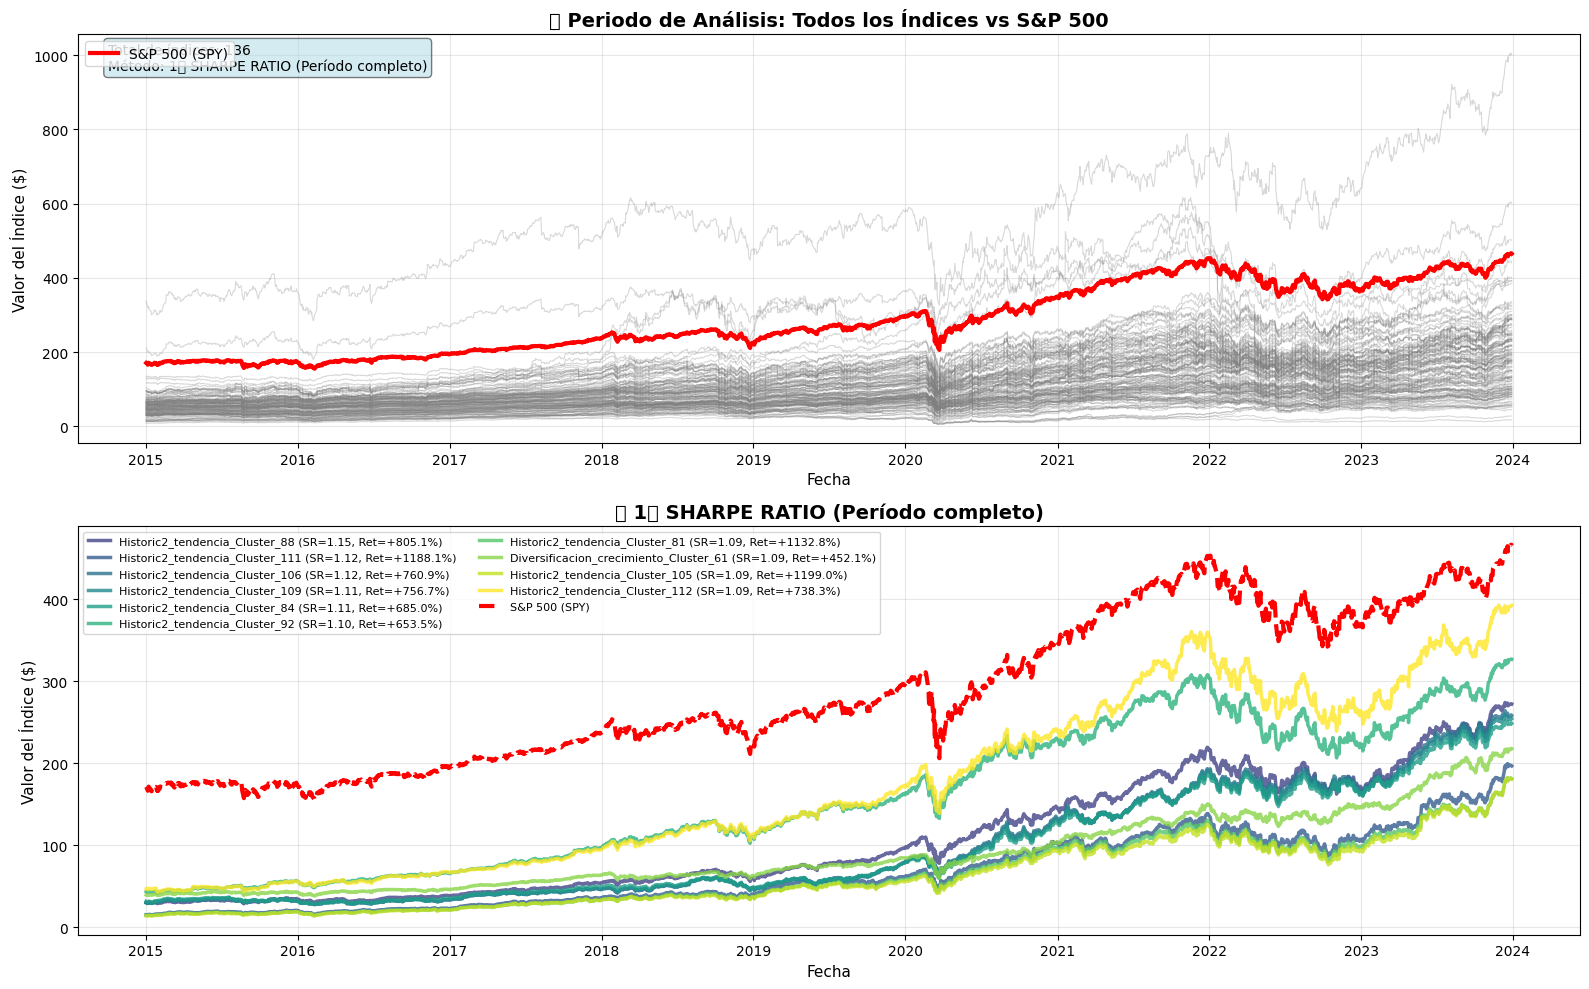


📊 COMPARACIÓN 1️⃣ SHARPE RATIO (Período completo) vs S&P 500:

📈 S&P 500 (SPY): +171.91%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_88: Ret=+805.09% (vs SPY: +633.19%), SR=1.15, Vol=23.9%
2. Historic2_tendencia_Cluster_111: Ret=+1188.10% (vs SPY: +1016.20%), SR=1.12, Vol=29.2%
3. Historic2_tendencia_Cluster_106: Ret=+760.92% (vs SPY: +589.01%), SR=1.12, Vol=24.1%
4. Historic2_tendencia_Cluster_109: Ret=+756.70% (vs SPY: +584.79%), SR=1.11, Vol=24.1%
5. Historic2_tendencia_Cluster_84: Ret=+685.05% (vs SPY: +513.14%), SR=1.11, Vol=23.2%
6. Historic2_tendencia_Cluster_92: Ret=+653.50% (vs SPY: +481.60%), SR=1.10, Vol=22.7%
7. Historic2_tendencia_Cluster_81: Ret=+1132.78% (vs SPY: +960.88%), SR=1.09, Vol=29.6%
8. Diversificacion_crecimiento_Cluster_61: Ret=+452.09% (vs SPY: +280.18%), SR=1.09, Vol=19.1%
9. Historic2_tendencia_Cluster_105: Ret=+1199.01% (vs SPY: +1027.10%), SR=1.09, Vol=30.6%
10. Historic2_tendencia_Cluster_112: Ret=+738.29% (vs SPY: +566.38%), SR=1.09, Vol=24.6%

 

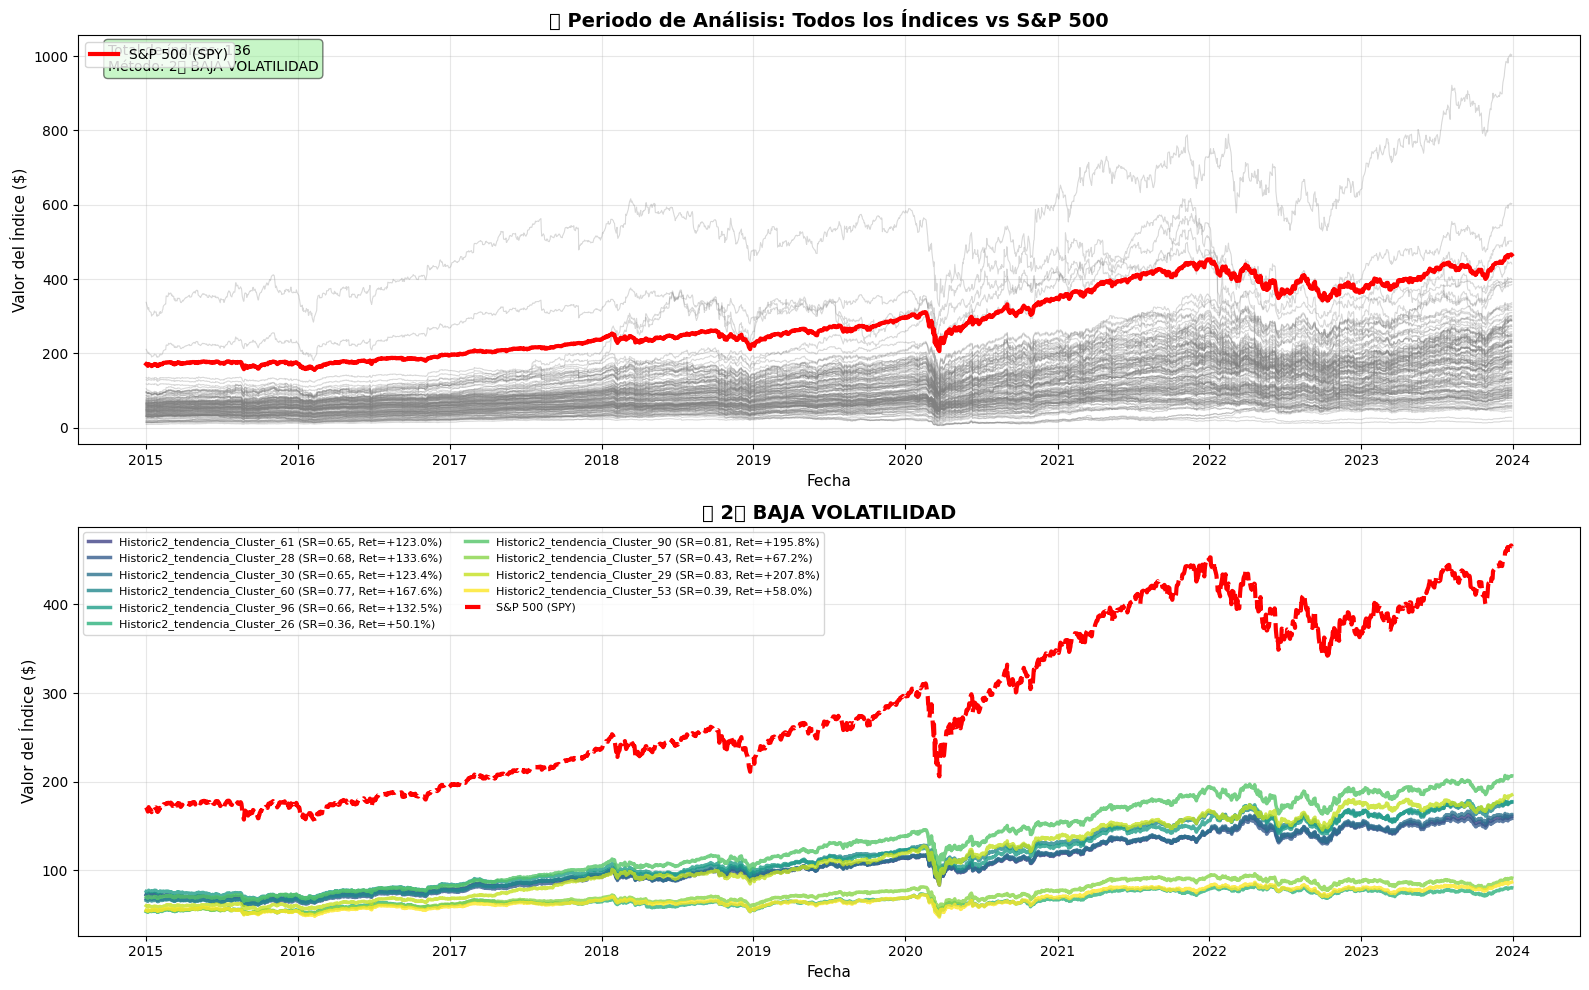


📊 COMPARACIÓN 2️⃣ BAJA VOLATILIDAD vs S&P 500:

📈 S&P 500 (SPY): +171.91%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_61: Ret=+123.02% (vs SPY: -48.88%), SR=0.65, Vol=15.6%
2. Historic2_tendencia_Cluster_28: Ret=+133.58% (vs SPY: -38.32%), SR=0.68, Vol=15.6%
3. Historic2_tendencia_Cluster_30: Ret=+123.40% (vs SPY: -48.50%), SR=0.65, Vol=15.8%
4. Historic2_tendencia_Cluster_60: Ret=+167.58% (vs SPY: -4.32%), SR=0.77, Vol=15.9%
5. Historic2_tendencia_Cluster_96: Ret=+132.55% (vs SPY: -39.36%), SR=0.66, Vol=16.2%
6. Historic2_tendencia_Cluster_26: Ret=+50.11% (vs SPY: -121.80%), SR=0.36, Vol=16.5%
7. Historic2_tendencia_Cluster_90: Ret=+195.80% (vs SPY: +23.90%), SR=0.81, Vol=16.6%
8. Historic2_tendencia_Cluster_57: Ret=+67.16% (vs SPY: -104.75%), SR=0.43, Vol=16.8%
9. Historic2_tendencia_Cluster_29: Ret=+207.75% (vs SPY: +35.85%), SR=0.83, Vol=16.9%
10. Historic2_tendencia_Cluster_53: Ret=+58.02% (vs SPY: -113.88%), SR=0.39, Vol=16.9%

  VISUALIZACIÓN: 3️⃣ SCORE BALANCEADO


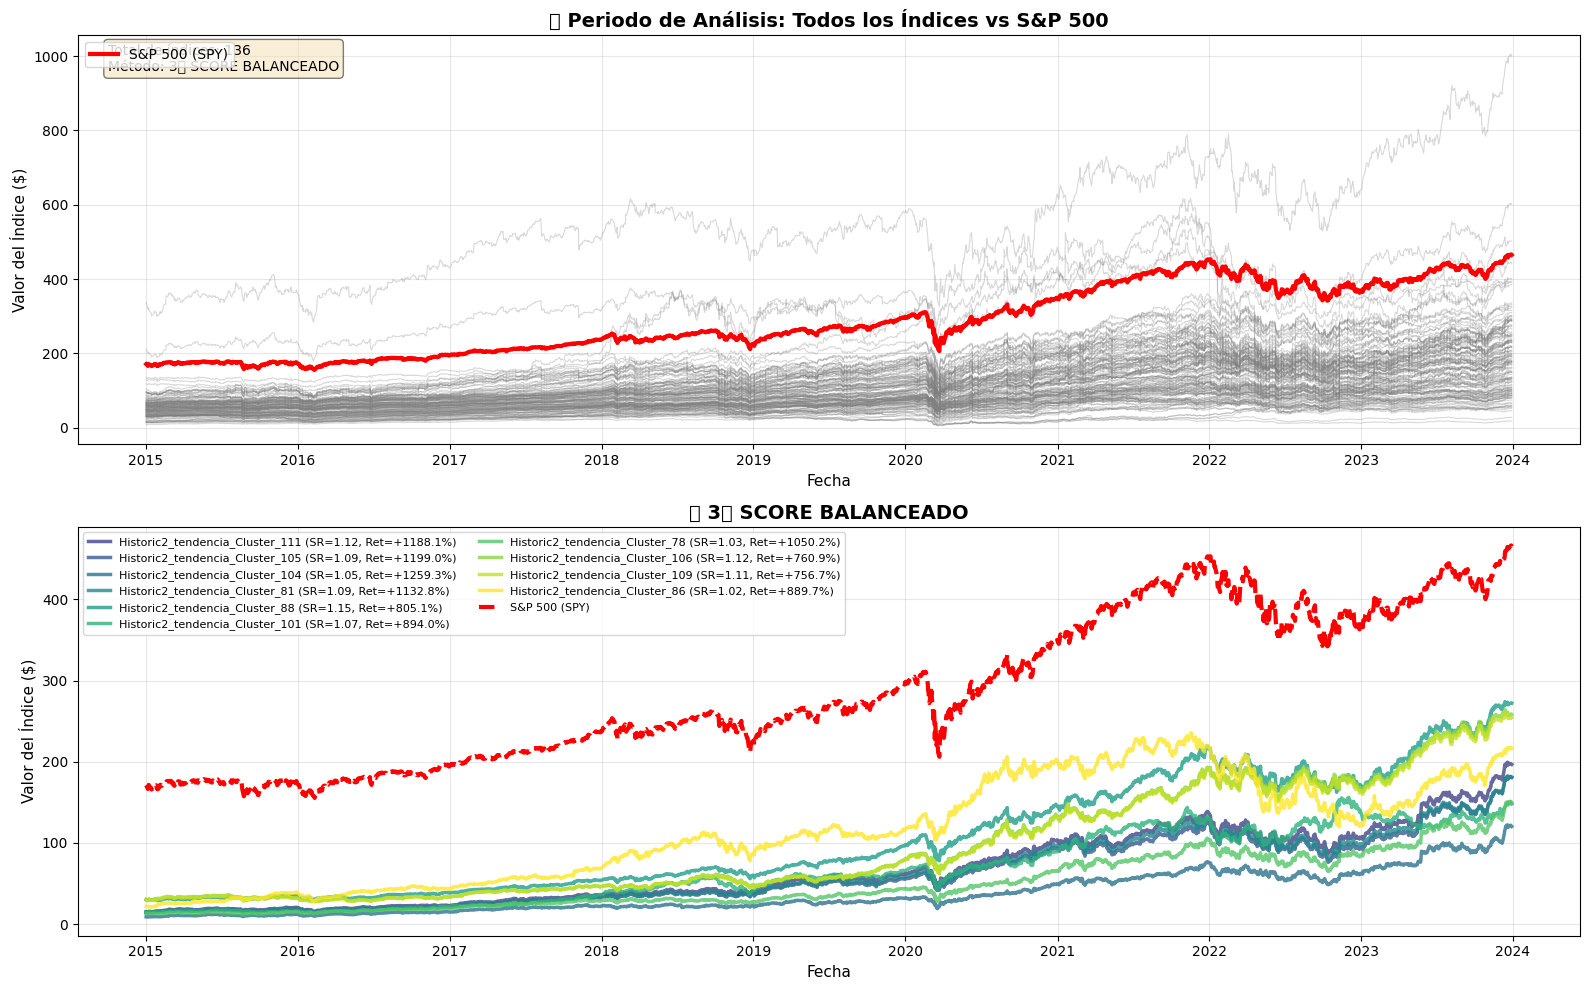


📊 COMPARACIÓN 3️⃣ SCORE BALANCEADO vs S&P 500:

📈 S&P 500 (SPY): +171.91%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_111: Ret=+1188.10% (vs SPY: +1016.20%), SR=1.12, Vol=29.2%
2. Historic2_tendencia_Cluster_105: Ret=+1199.01% (vs SPY: +1027.10%), SR=1.09, Vol=30.6%
3. Historic2_tendencia_Cluster_104: Ret=+1259.28% (vs SPY: +1087.37%), SR=1.05, Vol=32.8%
4. Historic2_tendencia_Cluster_81: Ret=+1132.78% (vs SPY: +960.88%), SR=1.09, Vol=29.6%
5. Historic2_tendencia_Cluster_88: Ret=+805.09% (vs SPY: +633.19%), SR=1.15, Vol=23.9%
6. Historic2_tendencia_Cluster_101: Ret=+893.99% (vs SPY: +722.09%), SR=1.07, Vol=27.5%
7. Historic2_tendencia_Cluster_78: Ret=+1050.19% (vs SPY: +878.29%), SR=1.03, Vol=31.2%
8. Historic2_tendencia_Cluster_106: Ret=+760.92% (vs SPY: +589.01%), SR=1.12, Vol=24.1%
9. Historic2_tendencia_Cluster_109: Ret=+756.70% (vs SPY: +584.79%), SR=1.11, Vol=24.1%
10. Historic2_tendencia_Cluster_86: Ret=+889.71% (vs SPY: +717.80%), SR=1.02, Vol=29.1%

  VISUALIZACIÓN: 4️⃣

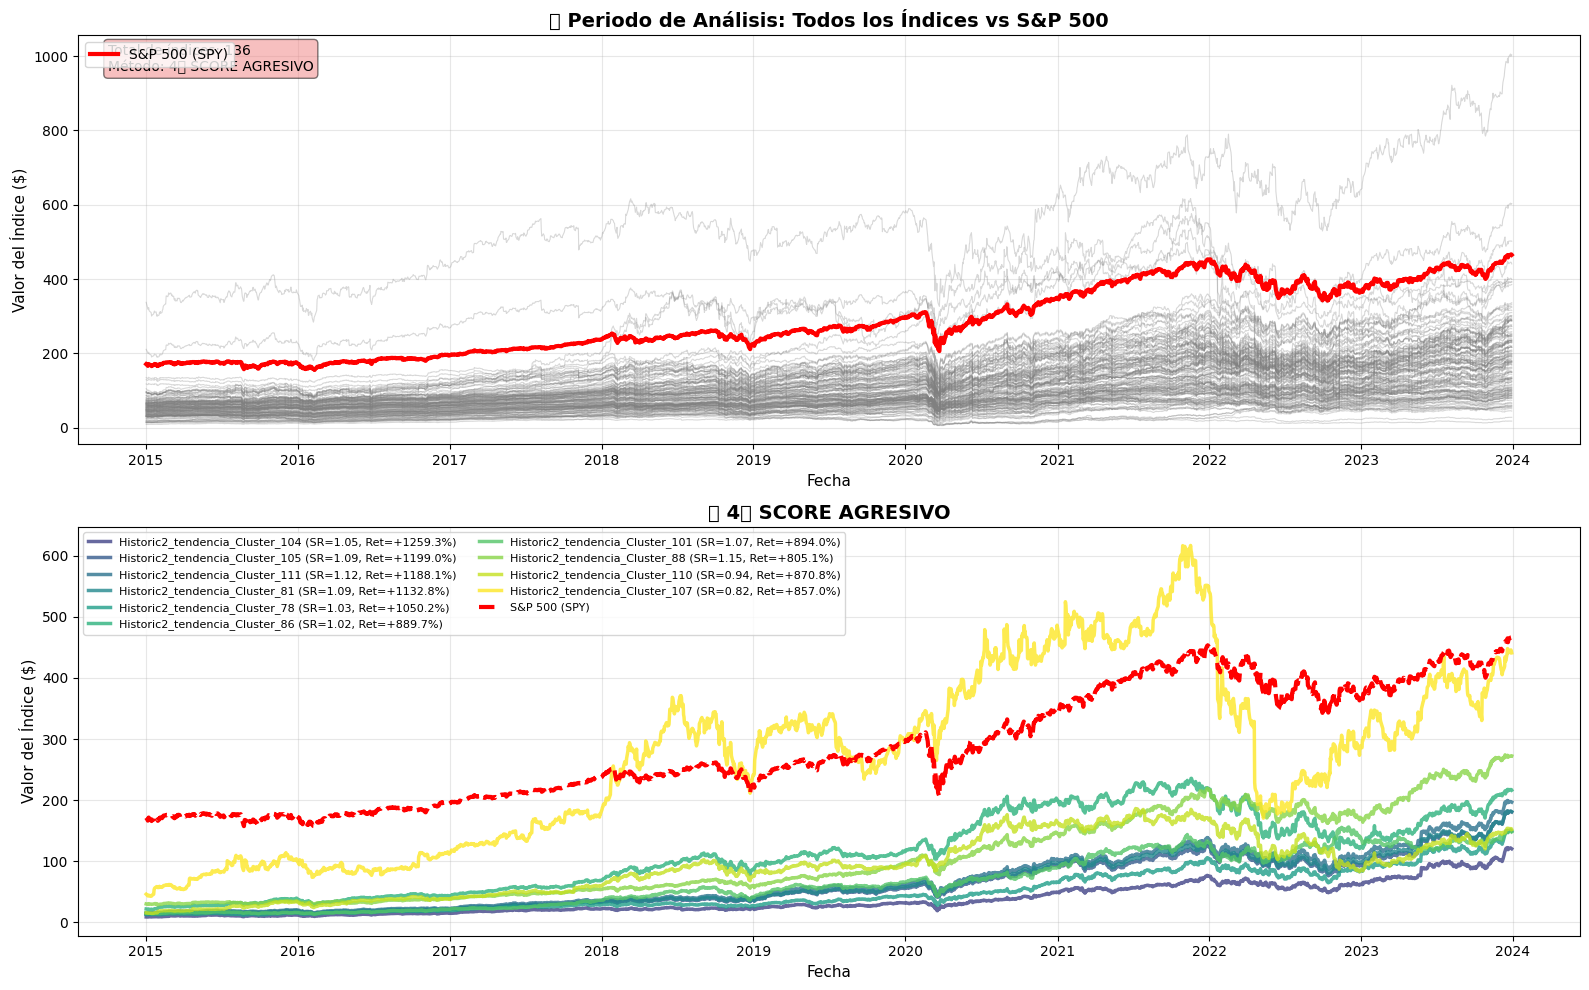


📊 COMPARACIÓN 4️⃣ SCORE AGRESIVO vs S&P 500:

📈 S&P 500 (SPY): +171.91%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_104: Ret=+1259.28% (vs SPY: +1087.37%), SR=1.05, Vol=32.8%
2. Historic2_tendencia_Cluster_105: Ret=+1199.01% (vs SPY: +1027.10%), SR=1.09, Vol=30.6%
3. Historic2_tendencia_Cluster_111: Ret=+1188.10% (vs SPY: +1016.20%), SR=1.12, Vol=29.2%
4. Historic2_tendencia_Cluster_81: Ret=+1132.78% (vs SPY: +960.88%), SR=1.09, Vol=29.6%
5. Historic2_tendencia_Cluster_78: Ret=+1050.19% (vs SPY: +878.29%), SR=1.03, Vol=31.2%
6. Historic2_tendencia_Cluster_86: Ret=+889.71% (vs SPY: +717.80%), SR=1.02, Vol=29.1%
7. Historic2_tendencia_Cluster_101: Ret=+893.99% (vs SPY: +722.09%), SR=1.07, Vol=27.5%
8. Historic2_tendencia_Cluster_88: Ret=+805.09% (vs SPY: +633.19%), SR=1.15, Vol=23.9%
9. Historic2_tendencia_Cluster_110: Ret=+870.78% (vs SPY: +698.87%), SR=0.94, Vol=32.7%
10. Historic2_tendencia_Cluster_107: Ret=+856.96% (vs SPY: +685.06%), SR=0.82, Vol=41.4%

  VISUALIZACIÓN: 5️⃣ S

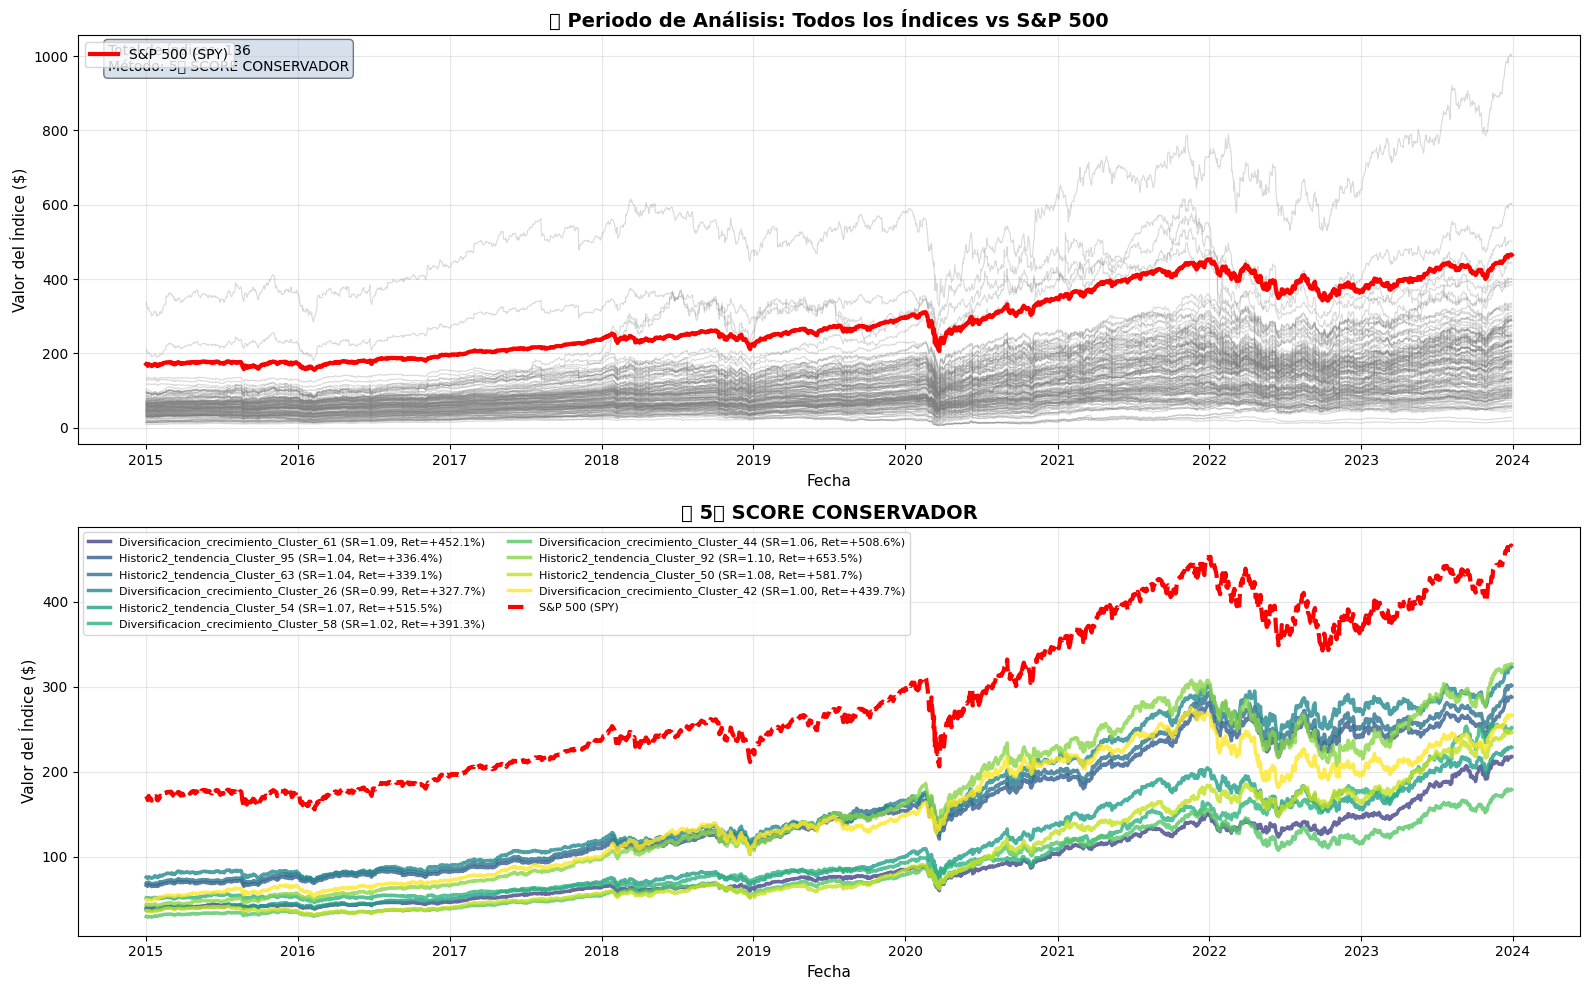


📊 COMPARACIÓN 5️⃣ SCORE CONSERVADOR vs S&P 500:

📈 S&P 500 (SPY): +171.91%

🔝 TOP 10 ÍNDICES:
1. Diversificacion_crecimiento_Cluster_61: Ret=+452.09% (vs SPY: +280.18%), SR=1.09, Vol=19.1%
2. Historic2_tendencia_Cluster_95: Ret=+336.44% (vs SPY: +164.54%), SR=1.04, Vol=17.2%
3. Historic2_tendencia_Cluster_63: Ret=+339.05% (vs SPY: +167.15%), SR=1.04, Vol=17.3%
4. Diversificacion_crecimiento_Cluster_26: Ret=+327.73% (vs SPY: +155.82%), SR=0.99, Vol=18.0%
5. Historic2_tendencia_Cluster_54: Ret=+515.48% (vs SPY: +343.57%), SR=1.07, Vol=21.1%
6. Diversificacion_crecimiento_Cluster_58: Ret=+391.29% (vs SPY: +219.38%), SR=1.02, Vol=19.2%
7. Diversificacion_crecimiento_Cluster_44: Ret=+508.60% (vs SPY: +336.69%), SR=1.06, Vol=21.0%
8. Historic2_tendencia_Cluster_92: Ret=+653.50% (vs SPY: +481.60%), SR=1.10, Vol=22.7%
9. Historic2_tendencia_Cluster_50: Ret=+581.75% (vs SPY: +409.84%), SR=1.08, Vol=22.1%
10. Diversificacion_crecimiento_Cluster_42: Ret=+439.72% (vs SPY: +267.81%), SR=1.00, Vol=

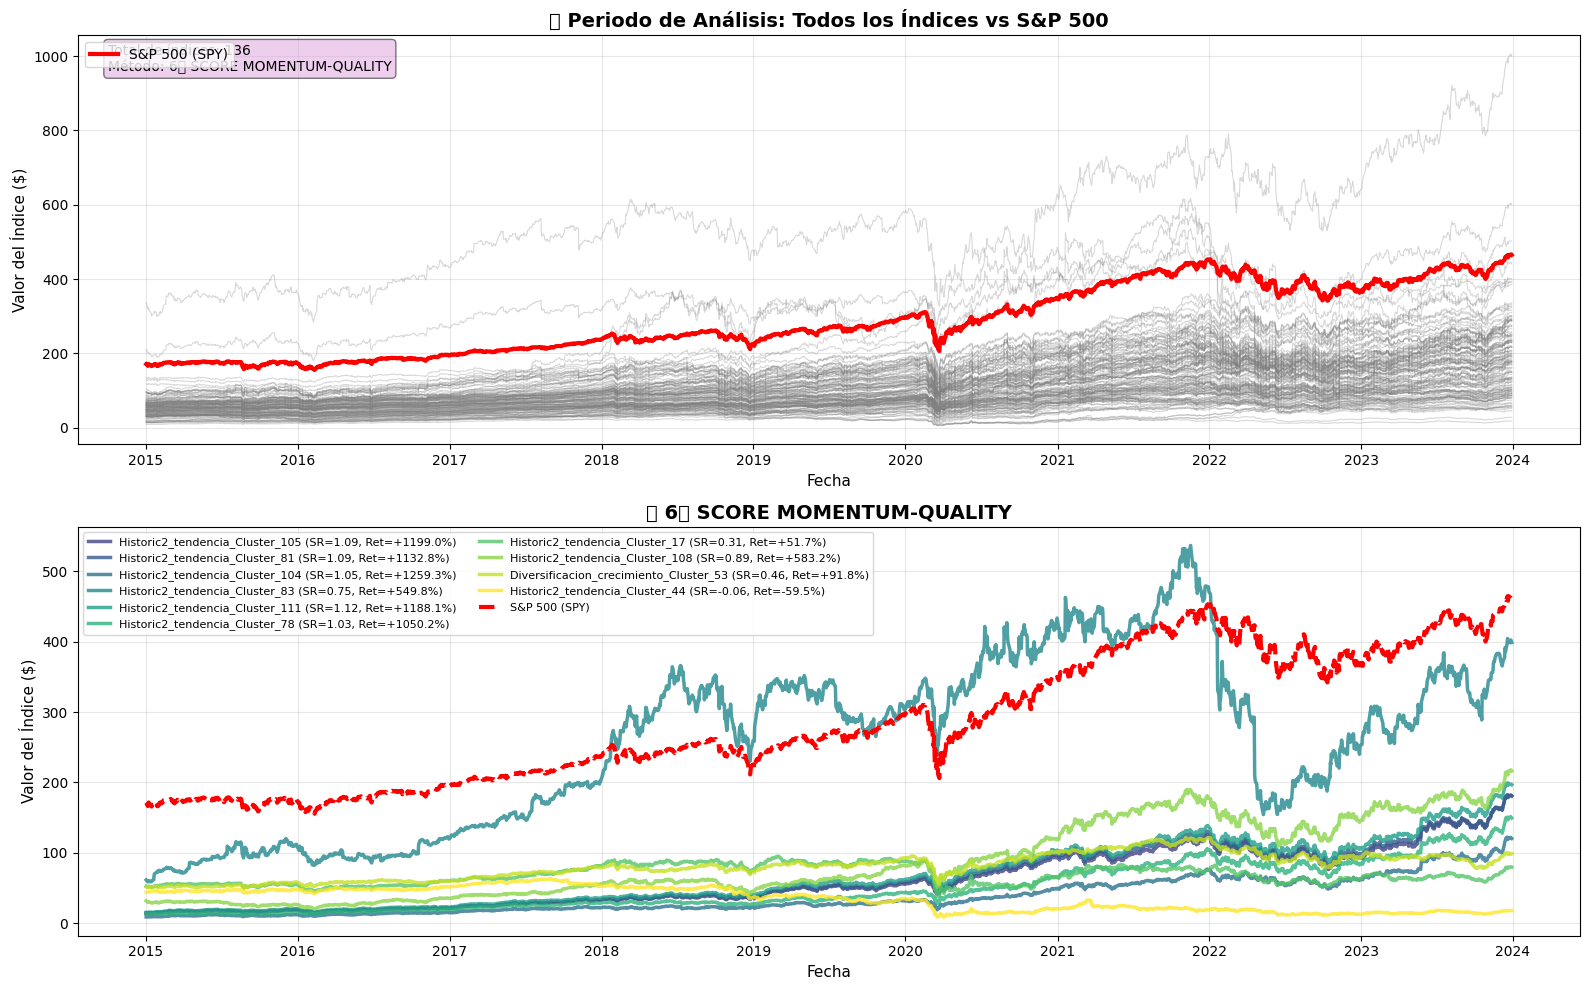


📊 COMPARACIÓN 6️⃣ SCORE MOMENTUM-QUALITY vs S&P 500:

📈 S&P 500 (SPY): +171.91%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_105: Ret=+1199.01% (vs SPY: +1027.10%), SR=1.09, Vol=30.6%
2. Historic2_tendencia_Cluster_81: Ret=+1132.78% (vs SPY: +960.88%), SR=1.09, Vol=29.6%
3. Historic2_tendencia_Cluster_104: Ret=+1259.28% (vs SPY: +1087.37%), SR=1.05, Vol=32.8%
4. Historic2_tendencia_Cluster_83: Ret=+549.79% (vs SPY: +377.89%), SR=0.75, Vol=36.7%
5. Historic2_tendencia_Cluster_111: Ret=+1188.10% (vs SPY: +1016.20%), SR=1.12, Vol=29.2%
6. Historic2_tendencia_Cluster_78: Ret=+1050.19% (vs SPY: +878.29%), SR=1.03, Vol=31.2%
7. Historic2_tendencia_Cluster_17: Ret=+51.69% (vs SPY: -120.22%), SR=0.31, Vol=27.9%
8. Historic2_tendencia_Cluster_108: Ret=+583.21% (vs SPY: +411.30%), SR=0.89, Vol=28.6%
9. Diversificacion_crecimiento_Cluster_53: Ret=+91.79% (vs SPY: -80.11%), SR=0.46, Vol=20.2%
10. Historic2_tendencia_Cluster_44: Ret=-59.51% (vs SPY: -231.42%), SR=-0.06, Vol=38.8%

✅ VISUALIZA

In [96]:
# =======================================================
# 📊 VISUALIZACIONES POR CADA MÉTODO DE CALIFICACIÓN
# =======================================================

# SPY series para comparación
spy_series = SPY_analysis['SPY'] if isinstance(SPY_analysis, pd.DataFrame) else SPY_analysis
spy_return = ((spy_series.iloc[-1] / spy_series.iloc[0]) - 1) * 100

# Crear visualizaciones para cada método
for score_col, method_info in ranking_methods.items():
    print("\n" + "=" * 100)
    print(f"  VISUALIZACIÓN: {method_info['name']}")
    print("=" * 100)
    
    # Obtener Top 10 de este método
    top_10_clusters = all_rankings[score_col]
    
    # Crear figura con 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # --- SUBPLOT 1: TODOS LOS ÍNDICES + SPY ---
    ax1 = axes[0]
    
    # Graficar todos los índices en gris
    for cluster_name, cluster_data in cluster_indices.items():
        ax1.plot(cluster_data['index'], alpha=0.3, linewidth=0.8, color='gray')
    
    # SPY destacado
    ax1.plot(spy_series.index, spy_series, linewidth=3, color='red', 
             label='S&P 500 (SPY)', zorder=10)
    
    ax1.set_title('📊 Periodo de Análisis: Todos los Índices vs S&P 500', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Fecha', fontsize=11)
    ax1.set_ylabel('Valor del Índice ($)', fontsize=11)
    ax1.legend(fontsize=10, loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Agregar texto informativo
    ax1.text(0.02, 0.98, f'Total de índices: {len(cluster_indices)}\nMétodo: {method_info["name"]}', 
             transform=ax1.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=method_info['color'], alpha=0.5))
    
    # --- SUBPLOT 2: TOP 10 DE ESTE MÉTODO ---
    ax2 = axes[1]
    
    # Colores para los Top 10
    colors = plt.cm.viridis(np.linspace(0.2, 1, len(top_10_clusters)))
    
    for i, cluster_name in enumerate(top_10_clusters):
        cluster_data = cluster_indices[cluster_name]
        sharpe = cluster_data['metrics']['sharpe_ratio']
        retorno = cluster_data['metrics']['retorno_total'] * 100
        
        ax2.plot(cluster_data['index'], linewidth=2.5, alpha=0.8, color=colors[i],
                 label=f"{cluster_name} (SR={sharpe:.2f}, Ret={retorno:+.1f}%)")
    
    # SPY destacado
    ax2.plot(spy_series.index, spy_series, linewidth=3, color='red', 
             label='S&P 500 (SPY)', linestyle='--', zorder=10)
    
    ax2.set_title(f'🔝 {method_info["name"]}', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=11)
    ax2.set_ylabel('Valor del Índice ($)', fontsize=11)
    ax2.legend(fontsize=8, loc='upper left', ncol=2)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- ESTADÍSTICAS COMPARATIVAS ---
    print(f"\n📊 COMPARACIÓN {method_info['name']} vs S&P 500:")
    print(f"\n📈 S&P 500 (SPY): {spy_return:+.2f}%")
    
    print(f"\n🔝 TOP 10 ÍNDICES:")
    for i, cluster_name in enumerate(top_10_clusters, 1):
        metrics = cluster_indices[cluster_name]['metrics']
        sharpe = metrics['sharpe_ratio']
        retorno = metrics['retorno_total'] * 100
        diferencia = retorno - spy_return
        volatilidad = metrics['volatilidad'] * 100
        
        print(f"{i}. {cluster_name}: Ret={retorno:+.2f}% (vs SPY: {diferencia:+.2f}%), SR={sharpe:.2f}, Vol={volatilidad:.1f}%")

print("\n" + "=" * 100)
print("✅ VISUALIZACIONES COMPLETADAS PARA TODOS LOS MÉTODOS")
print("=" * 100)

In [97]:
###

## Validación

In [98]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=validation_data,
    market_caps_dict=market_caps,
    start_value=1,
    normalized=True
)

# Paso 3: Crear tabla resumen con métricas DE VALIDACIÓN
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES VALIDACIÓN - PERFORMANCE OUT-OF-SAMPLE")
print("=" * 100)

summary_data_val = []
for cluster_name, cluster_data in cluster_indices.items():
    summary_data_val.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'] * 100,
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'] * 100,
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'] * 100,
        'Tendencia': cluster_data['metrics']['tendencia'],
        'R²': cluster_data['metrics']['r_squared'],
        'Valor Inicial': cluster_data['metrics']['valor_inicial'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df_val = pd.DataFrame(summary_data_val)

print("\n\n📊 ESTADÍSTICAS GENERALES EN VALIDACIÓN:")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df_val['Sharpe Ratio'].mean():.4f}")
print(f"   📊 R² promedio: {summary_df_val['R²'].mean():.4f}")
print(f"   💹 Retorno promedio: {summary_df_val['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df_val['Volatilidad (%)'].mean():.2f}%")
print(f"   📉 Max Drawdown promedio: {summary_df_val['Max Drawdown (%)'].mean():.2f}%")
print(f"   💰 Valor inicial promedio: ${summary_df_val['Valor Inicial'].mean():.2f}")
print(f"   💵 Valor final promedio: ${summary_df_val['Valor Final'].mean():.2f}")

🔍 Verificando datos necesarios...
   ✓ all_clusters: 136 clusters
   ✓ tickers_data: (2264, 464)
   ✓ market_caps: 464 tickers con capitalización

  RESUMEN DE ÍNDICES VALIDACIÓN - PERFORMANCE OUT-OF-SAMPLE


📊 ESTADÍSTICAS GENERALES EN VALIDACIÓN:
   ⭐ Sharpe Ratio promedio: 1.1010
   📊 R² promedio: 0.4627
   💹 Retorno promedio: 50.48%
   📊 Volatilidad promedio: 21.64%
   📉 Max Drawdown promedio: -21.82%
   💰 Valor inicial promedio: $1.00
   💵 Valor final promedio: $1.50

  RESUMEN DE ÍNDICES VALIDACIÓN - PERFORMANCE OUT-OF-SAMPLE


📊 ESTADÍSTICAS GENERALES EN VALIDACIÓN:
   ⭐ Sharpe Ratio promedio: 1.1010
   📊 R² promedio: 0.4627
   💹 Retorno promedio: 50.48%
   📊 Volatilidad promedio: 21.64%
   📉 Max Drawdown promedio: -21.82%
   💰 Valor inicial promedio: $1.00
   💵 Valor final promedio: $1.50

  RESUMEN DE ÍNDICES VALIDACIÓN - PERFORMANCE OUT-OF-SAMPLE


📊 ESTADÍSTICAS GENERALES EN VALIDACIÓN:
   ⭐ Sharpe Ratio promedio: 1.1010
   📊 R² promedio: 0.4627
   💹 Retorno promedio: 50.48%

In [99]:
# =======================================================
# 📊 EVALUACIÓN DE CADA MÉTODO EN VALIDACIÓN (Out-of-Sample)
# =======================================================

# SPY de validación para comparación
spy_series_val = SPY_validation['SPY'] if isinstance(SPY_validation, pd.DataFrame) else SPY_validation
spy_return_val = ((spy_series_val.iloc[-1] / spy_series_val.iloc[0]) - 1) * 100

print("\n" + "=" * 100)
print("  COMPARACIÓN DE MÉTODOS: ANÁLISIS vs VALIDACIÓN")
print("=" * 100)
print(f"\n📈 S&P 500 en Validación: {spy_return_val:+.2f}%\n")

# Resultados de cada método
comparison_results = {}

for score_col, method_info in ranking_methods.items():
    print("=" * 100)
    print(f"  {method_info['name']}")
    print("=" * 100)
    
    # Top 10 seleccionados en ANÁLISIS
    top_10_analysis = all_rankings[score_col]
    
    # Performance de esos Top 10 en VALIDACIÓN
    validation_metrics = []
    for cluster_name in top_10_analysis:
        if cluster_name in cluster_indices:
            val_metrics = cluster_indices[cluster_name]['metrics']
            validation_metrics.append({
                'Cluster': cluster_name,
                'Sharpe Val': val_metrics['sharpe_ratio'],
                'Retorno Val (%)': val_metrics['retorno_total'] * 100,
                'Volatilidad Val (%)': val_metrics['volatilidad'] * 100,
                'Max DD Val (%)': val_metrics['max_drawdown'] * 100
            })
    
    val_df = pd.DataFrame(validation_metrics)
    
    # Mostrar resultados
    print(f"\n📊 Performance en VALIDACIÓN de los Top 10 seleccionados en ANÁLISIS:")
    print(val_df.to_string(index=False))
    
    # Estadísticas agregadas
    avg_sharpe_val = val_df['Sharpe Val'].mean()
    avg_ret_val = val_df['Retorno Val (%)'].mean()
    avg_vol_val = val_df['Volatilidad Val (%)'].mean()
    
    print(f"\n📈 ESTADÍSTICAS AGREGADAS EN VALIDACIÓN:")
    print(f"   ⭐ Sharpe Ratio promedio: {avg_sharpe_val:.4f}")
    print(f"   💹 Retorno promedio: {avg_ret_val:+.2f}%")
    print(f"   📊 Volatilidad promedio: {avg_vol_val:.2f}%")
    print(f"   🎯 vs SPY: {avg_ret_val - spy_return_val:+.2f}%")
    print(f"   🏆 Clusters que superan SPY: {sum(val_df['Retorno Val (%)'] > spy_return_val)}/10")
    
    # Guardar para comparación final
    comparison_results[score_col] = {
        'method_name': method_info['name'],
        'avg_sharpe_val': avg_sharpe_val,
        'avg_return_val': avg_ret_val,
        'avg_vol_val': avg_vol_val,
        'vs_spy': avg_ret_val - spy_return_val,
        'clusters_beat_spy': sum(val_df['Retorno Val (%)'] > spy_return_val),
        'top_10_clusters': top_10_analysis
    }
    print()

# =======================================================
# 🏆 COMPARACIÓN FINAL: ¿QUÉ MÉTODO FUNCIONA MEJOR?
# =======================================================

print("\n" + "=" * 120)
print("  🏆 RANKING DE MÉTODOS POR PERFORMANCE EN VALIDACIÓN")
print("=" * 120)

results_summary = []
for score_col, results in comparison_results.items():
    results_summary.append({
        'Método': results['method_name'],
        'Ret Val (%)': results['avg_return_val'],
        'vs SPY (%)': results['vs_spy'],
        'Sharpe Val': results['avg_sharpe_val'],
        'Vol Val (%)': results['avg_vol_val'],
        'Beat SPY': f"{results['clusters_beat_spy']}/10"
    })

results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values('Ret Val (%)', ascending=False)

print("\n📊 COMPARACIÓN DE TODOS LOS MÉTODOS (ordenado por Retorno en Validación):")
print(results_df.to_string(index=False))

print("\n" + "=" * 120)
print("  CONCLUSIONES:")
print("=" * 120)

best_method = results_df.iloc[0]
print(f"\n🥇 MEJOR MÉTODO POR RETORNO: {best_method['Método']}")
print(f"   Retorno promedio en validación: {best_method['Ret Val (%)']:+.2f}%")
print(f"   Superioridad vs SPY: {best_method['vs SPY (%)']:+.2f}%")
print(f"   Clusters que superan SPY: {best_method['Beat SPY']}")

best_sharpe_idx = results_df['Sharpe Val'].idxmax()
best_sharpe_method = results_df.loc[best_sharpe_idx]
print(f"\n🥇 MEJOR MÉTODO POR SHARPE RATIO: {best_sharpe_method['Método']}")
print(f"   Sharpe promedio en validación: {best_sharpe_method['Sharpe Val']:.4f}")
print(f"   Retorno promedio: {best_sharpe_method['Ret Val (%)']:+.2f}%")

best_consistency_idx = results_df['Beat SPY'].apply(lambda x: int(x.split('/')[0])).idxmax()
best_consistency_method = results_df.loc[best_consistency_idx]
print(f"\n🥇 MEJOR MÉTODO POR CONSISTENCIA: {best_consistency_method['Método']}")
print(f"   Clusters que superan SPY: {best_consistency_method['Beat SPY']}")
print(f"   Retorno promedio: {best_consistency_method['Ret Val (%)']:+.2f}%")

print("\n" + "=" * 120)


  COMPARACIÓN DE MÉTODOS: ANÁLISIS vs VALIDACIÓN

📈 S&P 500 en Validación: +47.44%

  1️⃣ SHARPE RATIO (Período completo)

📊 Performance en VALIDACIÓN de los Top 10 seleccionados en ANÁLISIS:
                               Cluster  Sharpe Val  Retorno Val (%)  Volatilidad Val (%)  Max DD Val (%)
        Historic2_tendencia_Cluster_88    1.290295        56.768980            20.754309      -22.859957
       Historic2_tendencia_Cluster_111    1.374344       117.794069            35.631306      -36.004183
       Historic2_tendencia_Cluster_106    1.091632        52.356210            23.701069      -24.798988
       Historic2_tendencia_Cluster_109    1.088050        52.095973            23.690121      -25.212798
        Historic2_tendencia_Cluster_84    1.096211        49.840273            22.520106      -23.909469
        Historic2_tendencia_Cluster_92    0.910489        30.729044            17.866919      -19.068311
        Historic2_tendencia_Cluster_81    1.418244       126.724005     


  VALIDACIÓN: 1️⃣ SHARPE RATIO (Período completo)

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_88: Ret=+56.77%, Sharpe=1.29
   2. Historic2_tendencia_Cluster_111: Ret=+117.79%, Sharpe=1.37
   3. Historic2_tendencia_Cluster_106: Ret=+52.36%, Sharpe=1.09
   4. Historic2_tendencia_Cluster_109: Ret=+52.10%, Sharpe=1.09
   5. Historic2_tendencia_Cluster_84: Ret=+49.84%, Sharpe=1.10
   6. Historic2_tendencia_Cluster_92: Ret=+30.73%, Sharpe=0.91
   7. Historic2_tendencia_Cluster_81: Ret=+126.72%, Sharpe=1.42
   8. Diversificacion_crecimiento_Cluster_61: Ret=+74.96%, Sharpe=1.38
   9. Historic2_tendencia_Cluster_105: Ret=+133.05%, Sharpe=1.42
   10. Historic2_tendencia_Cluster_112: Ret=+28.90%, Sharpe=0.81


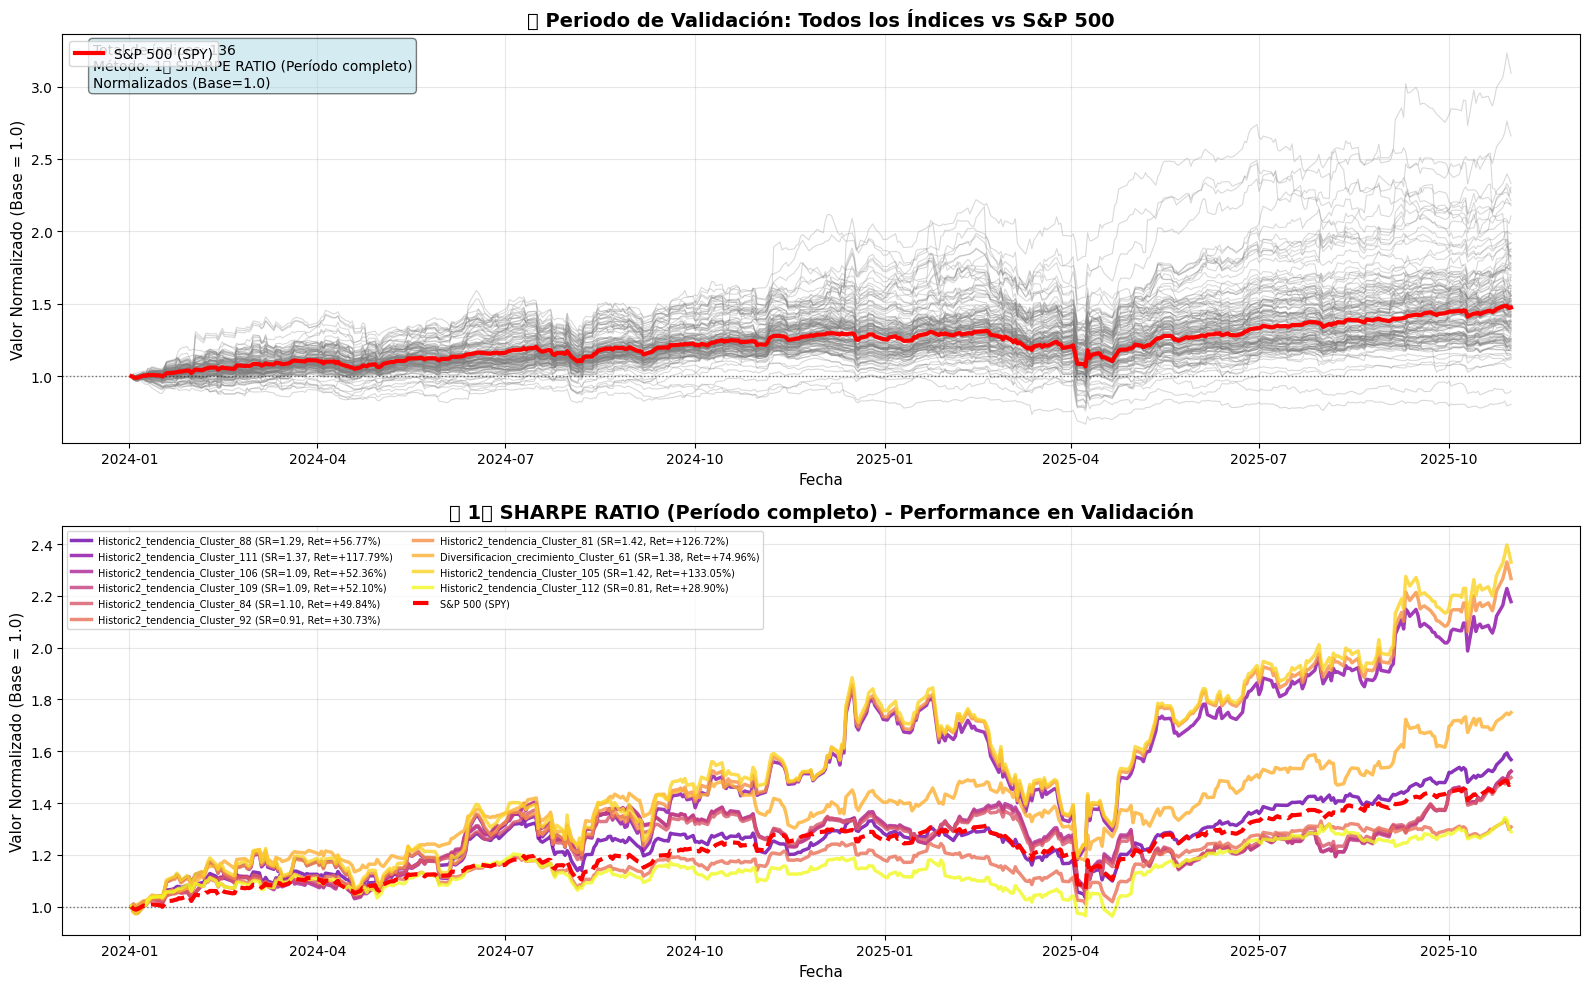


  VALIDACIÓN: 2️⃣ BAJA VOLATILIDAD

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_61: Ret=+26.19%, Sharpe=1.06
   2. Historic2_tendencia_Cluster_28: Ret=+24.77%, Sharpe=1.06
   3. Historic2_tendencia_Cluster_30: Ret=+26.14%, Sharpe=1.04
   4. Historic2_tendencia_Cluster_60: Ret=+21.42%, Sharpe=0.96
   5. Historic2_tendencia_Cluster_96: Ret=+25.32%, Sharpe=1.00
   6. Historic2_tendencia_Cluster_26: Ret=+56.76%, Sharpe=1.59
   7. Historic2_tendencia_Cluster_90: Ret=+19.58%, Sharpe=0.85
   8. Historic2_tendencia_Cluster_57: Ret=+45.88%, Sharpe=1.64
   9. Historic2_tendencia_Cluster_29: Ret=+18.83%, Sharpe=0.78
   10. Historic2_tendencia_Cluster_53: Ret=+50.96%, Sharpe=1.80


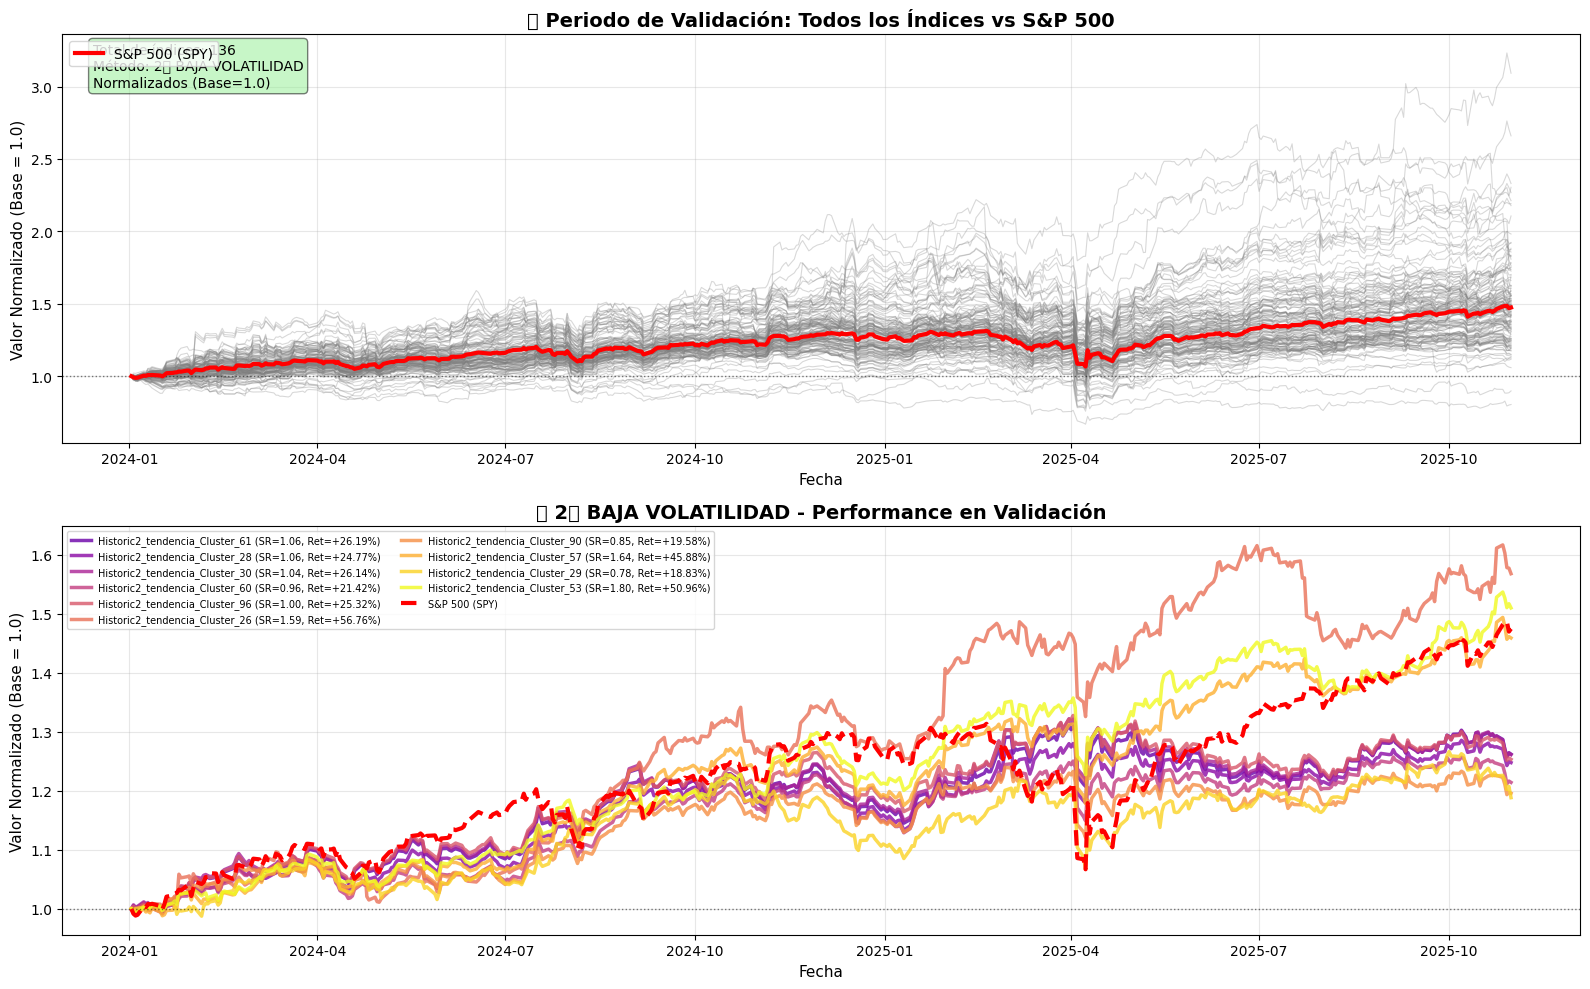


  VALIDACIÓN: 3️⃣ SCORE BALANCEADO

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_111: Ret=+117.79%, Sharpe=1.37
   2. Historic2_tendencia_Cluster_105: Ret=+133.05%, Sharpe=1.42
   3. Historic2_tendencia_Cluster_104: Ret=+209.17%, Sharpe=1.53
   4. Historic2_tendencia_Cluster_81: Ret=+126.72%, Sharpe=1.42
   5. Historic2_tendencia_Cluster_88: Ret=+56.77%, Sharpe=1.29
   6. Historic2_tendencia_Cluster_101: Ret=+58.77%, Sharpe=0.93
   7. Historic2_tendencia_Cluster_78: Ret=+165.97%, Sharpe=1.45
   8. Historic2_tendencia_Cluster_106: Ret=+52.36%, Sharpe=1.09
   9. Historic2_tendencia_Cluster_109: Ret=+52.10%, Sharpe=1.09
   10. Historic2_tendencia_Cluster_86: Ret=+42.98%, Sharpe=0.87


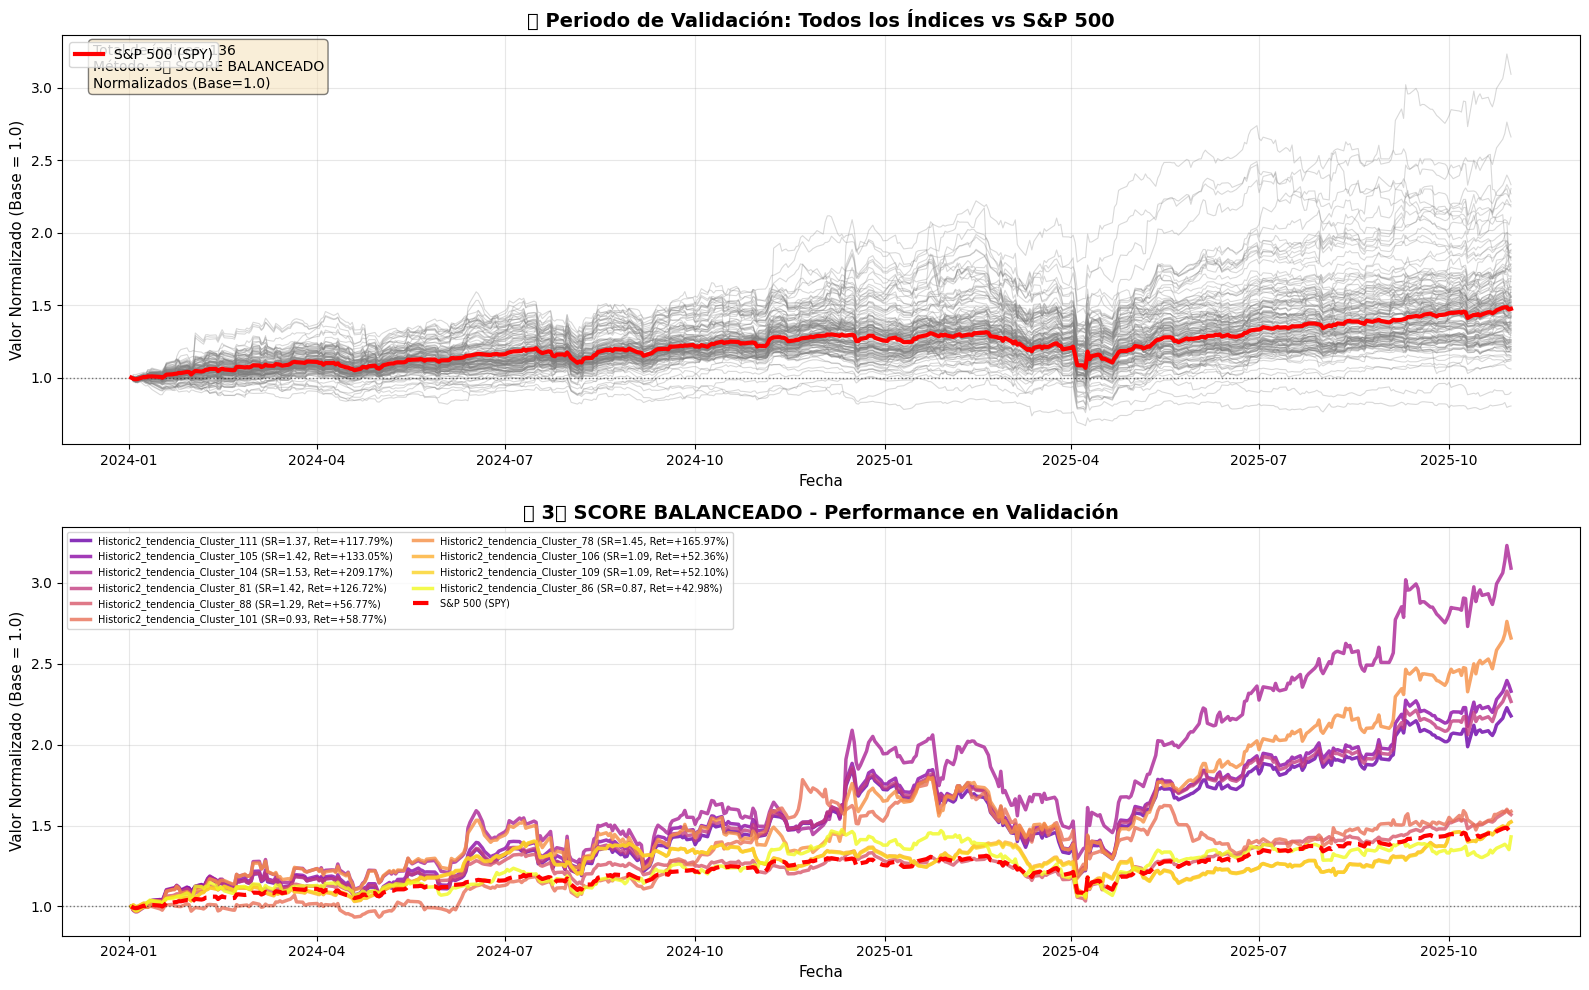


  VALIDACIÓN: 4️⃣ SCORE AGRESIVO

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_104: Ret=+209.17%, Sharpe=1.53
   2. Historic2_tendencia_Cluster_105: Ret=+133.05%, Sharpe=1.42
   3. Historic2_tendencia_Cluster_111: Ret=+117.79%, Sharpe=1.37
   4. Historic2_tendencia_Cluster_81: Ret=+126.72%, Sharpe=1.42
   5. Historic2_tendencia_Cluster_78: Ret=+165.97%, Sharpe=1.45
   6. Historic2_tendencia_Cluster_86: Ret=+42.98%, Sharpe=0.87
   7. Historic2_tendencia_Cluster_101: Ret=+58.77%, Sharpe=0.93
   8. Historic2_tendencia_Cluster_88: Ret=+56.77%, Sharpe=1.29
   9. Historic2_tendencia_Cluster_110: Ret=+62.72%, Sharpe=1.01
   10. Historic2_tendencia_Cluster_107: Ret=+130.43%, Sharpe=1.67


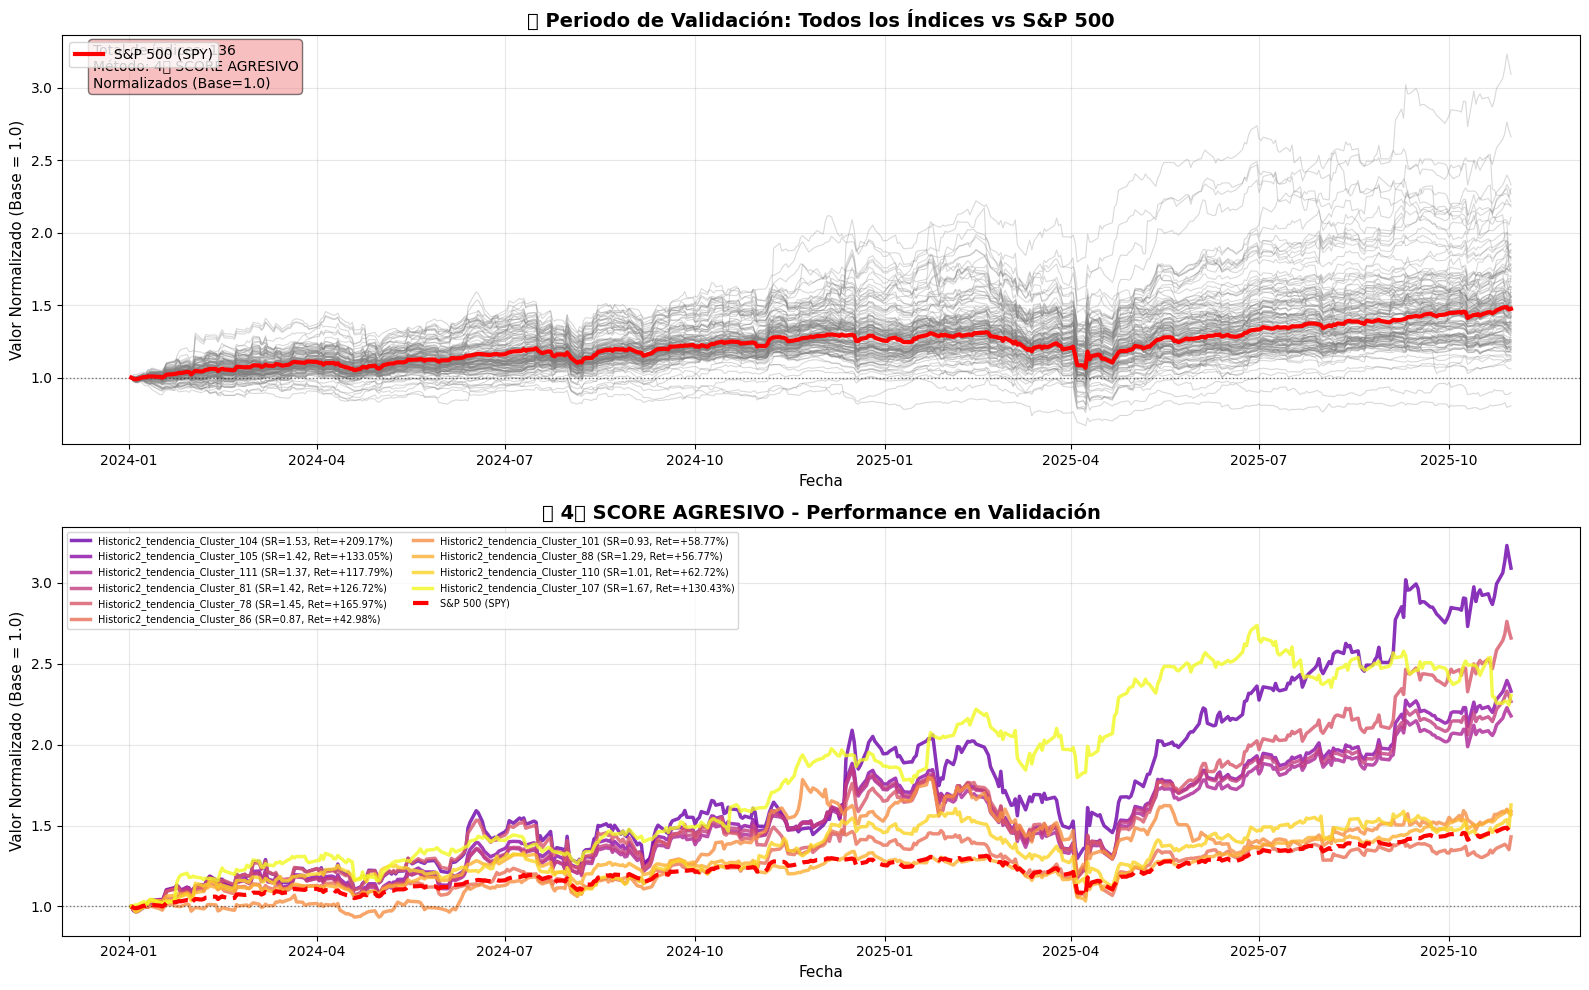


  VALIDACIÓN: 5️⃣ SCORE CONSERVADOR

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Diversificacion_crecimiento_Cluster_61: Ret=+74.96%, Sharpe=1.38
   2. Historic2_tendencia_Cluster_95: Ret=+20.52%, Sharpe=0.81
   3. Historic2_tendencia_Cluster_63: Ret=+20.30%, Sharpe=0.80
   4. Diversificacion_crecimiento_Cluster_26: Ret=+13.85%, Sharpe=0.58
   5. Historic2_tendencia_Cluster_54: Ret=+50.48%, Sharpe=1.32
   6. Diversificacion_crecimiento_Cluster_58: Ret=+55.68%, Sharpe=1.07
   7. Diversificacion_crecimiento_Cluster_44: Ret=+77.97%, Sharpe=1.60
   8. Historic2_tendencia_Cluster_92: Ret=+30.73%, Sharpe=0.91
   9. Historic2_tendencia_Cluster_50: Ret=+48.20%, Sharpe=1.13
   10. Diversificacion_crecimiento_Cluster_42: Ret=+37.73%, Sharpe=1.13


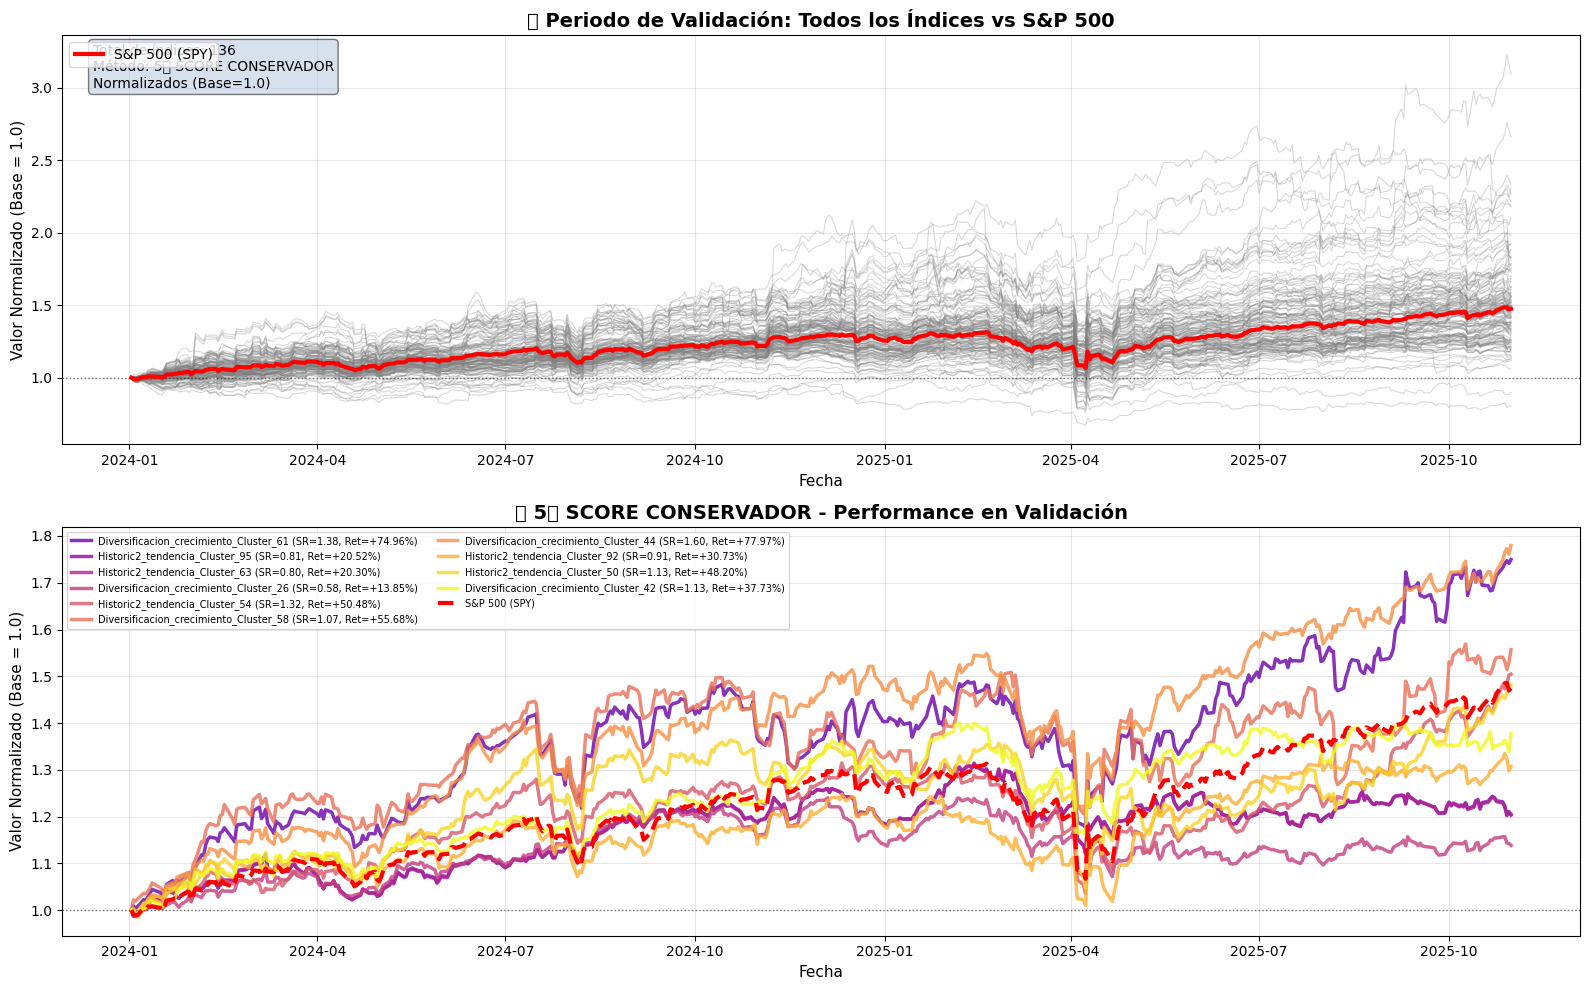


  VALIDACIÓN: 6️⃣ SCORE MOMENTUM-QUALITY

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_105: Ret=+133.05%, Sharpe=1.42
   2. Historic2_tendencia_Cluster_81: Ret=+126.72%, Sharpe=1.42
   3. Historic2_tendencia_Cluster_104: Ret=+209.17%, Sharpe=1.53
   4. Historic2_tendencia_Cluster_83: Ret=+110.62%, Sharpe=1.53
   5. Historic2_tendencia_Cluster_111: Ret=+117.79%, Sharpe=1.37
   6. Historic2_tendencia_Cluster_78: Ret=+165.97%, Sharpe=1.45
   7. Historic2_tendencia_Cluster_17: Ret=+24.30%, Sharpe=0.66
   8. Historic2_tendencia_Cluster_108: Ret=+49.16%, Sharpe=0.93
   9. Diversificacion_crecimiento_Cluster_53: Ret=+38.35%, Sharpe=0.95
   10. Historic2_tendencia_Cluster_44: Ret=+25.48%, Sharpe=0.57


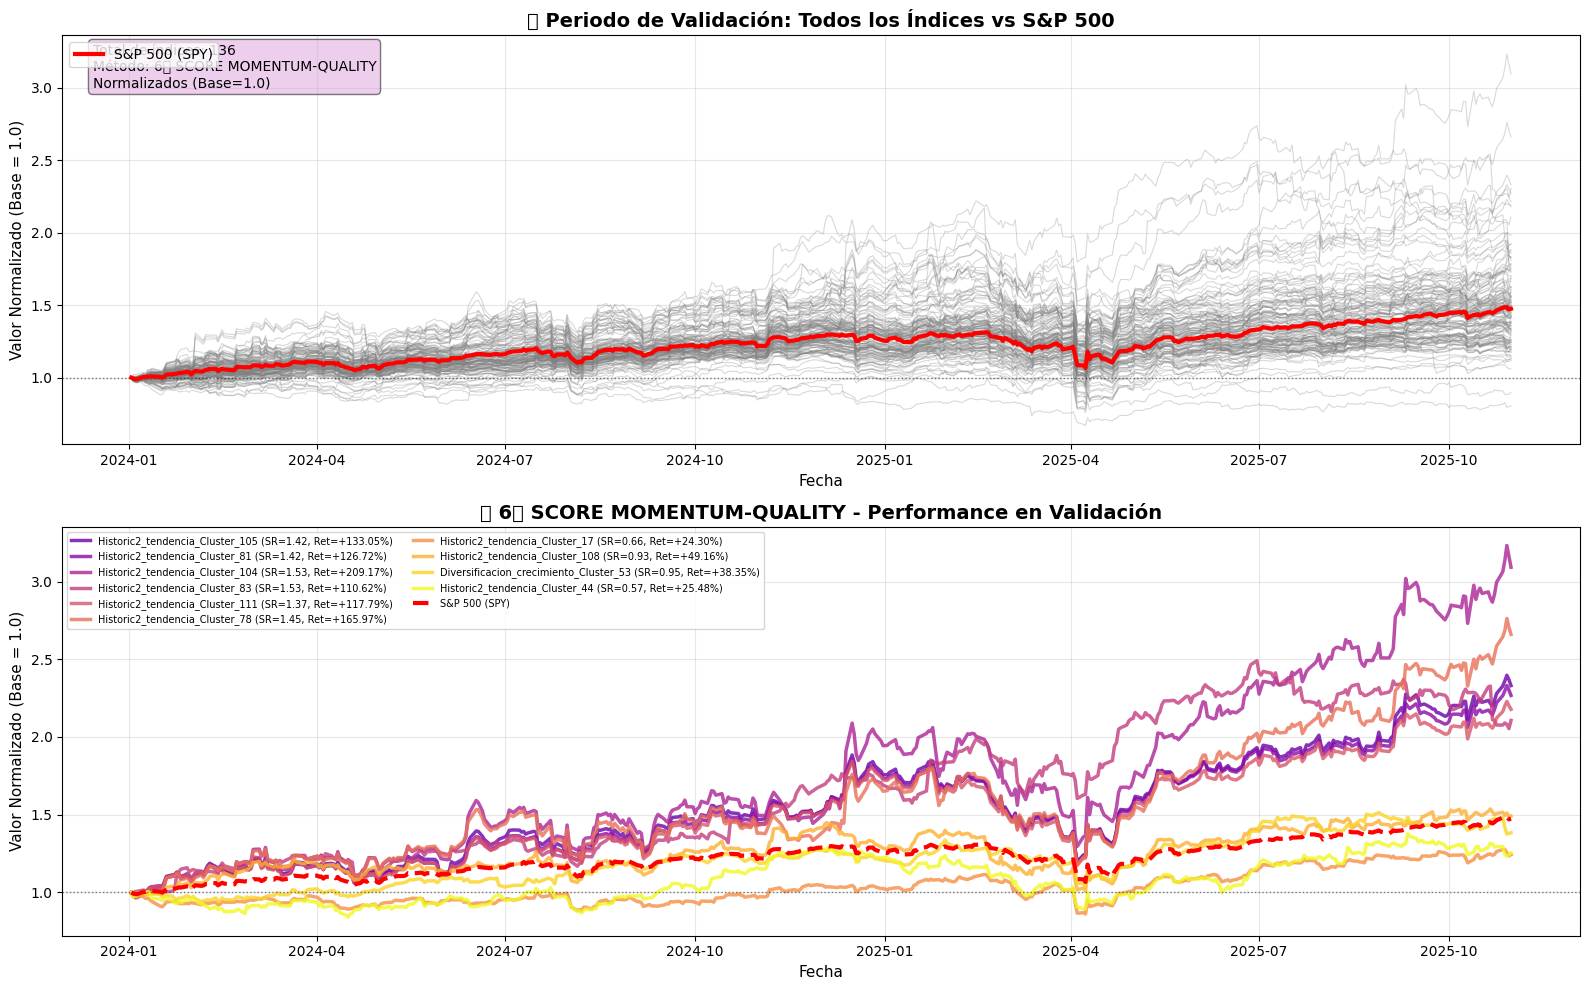


✅ VISUALIZACIONES DE VALIDACIÓN COMPLETADAS PARA TODOS LOS MÉTODOS

📊 TOP 10 ÍNDICES EN VALIDACIÓN (ORDENADOS POR SHARPE Y RETORNO)

🏆 TOP 10 POR SHARPE RATIO:
                               Cluster  Sharpe Ratio  Retorno (%)  Volatilidad (%)  Max Drawdown (%)
        Historic2_tendencia_Cluster_41      2.018104   119.111633        22.574717        -22.327767
Diversificacion_crecimiento_Cluster_57      1.799258    82.470758        19.357186        -19.145817
        Historic2_tendencia_Cluster_53      1.797611    50.964484        13.029844         -9.574639
        Historic2_tendencia_Cluster_24      1.755058    49.106168        12.953661        -10.934507
Diversificacion_crecimiento_Cluster_32      1.702472    66.191582        17.220853        -18.653720
       Historic2_tendencia_Cluster_107      1.672851   130.425218        30.049528        -19.015384
Diversificacion_crecimiento_Cluster_59      1.663980    91.920539        23.066064        -20.873210
        Historic2_tendencia_Clu

In [100]:
# =======================================================
# 📊 VISUALIZACIONES EN VALIDACIÓN POR CADA MÉTODO
# =======================================================

import matplotlib.pyplot as plt

# SPY de validación (normalizado)
spy_series_val = SPY_validation['SPY'] if isinstance(SPY_validation, pd.DataFrame) else SPY_validation
spy_normalized = spy_series_val / spy_series_val.iloc[0]

# Crear visualizaciones para cada método en VALIDACIÓN
for score_col, method_info in ranking_methods.items():
    print("\n" + "=" * 100)
    print(f"  VALIDACIÓN: {method_info['name']}")
    print("=" * 100)
    
    # Top 10 seleccionados en ANÁLISIS
    top_10_analysis = comparison_results[score_col]['top_10_clusters']
    
    # Crear figura con 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # --- SUBPLOT 1: TODOS LOS ÍNDICES + SPY ---
    ax1 = axes[0]
    
    # Graficar todos los índices en gris
    for cluster_name, cluster_data in cluster_indices.items():
        ax1.plot(cluster_data['index'], alpha=0.3, linewidth=0.8, color='gray')
    
    # SPY destacado
    ax1.plot(spy_normalized.index, spy_normalized, linewidth=3, color='red', 
             label='S&P 500 (SPY)', zorder=10)
    
    ax1.set_title('📊 Periodo de Validación: Todos los Índices vs S&P 500', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Fecha', fontsize=11)
    ax1.set_ylabel('Valor Normalizado (Base = 1.0)', fontsize=11)
    ax1.legend(fontsize=10, loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    # Agregar texto informativo
    ax1.text(0.02, 0.98, f'Total de índices: {len(cluster_indices)}\nMétodo: {method_info["name"]}\nNormalizados (Base=1.0)', 
             transform=ax1.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=method_info['color'], alpha=0.5))
    
    # --- SUBPLOT 2: TOP 10 DE ESTE MÉTODO (Performance en Validación) ---
    ax2 = axes[1]
    
    colors = plt.cm.plasma(np.linspace(0.2, 1, len(top_10_analysis)))
    
    print(f"\n📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:")
    for i, cluster_name in enumerate(top_10_analysis):
        if cluster_name in cluster_indices:
            cluster_data = cluster_indices[cluster_name]
            retorno_val = cluster_data['metrics']['retorno_total'] * 100
            sharpe_val = cluster_data['metrics']['sharpe_ratio']
            
            ax2.plot(cluster_data['index'], linewidth=2.5, alpha=0.8, color=colors[i],
                     label=f"{cluster_name} (SR={sharpe_val:.2f}, Ret={retorno_val:+.2f}%)")
            
            print(f"   {i+1}. {cluster_name}: Ret={retorno_val:+.2f}%, Sharpe={sharpe_val:.2f}")
        else:
            print(f"   ⚠️  {cluster_name}: No encontrado")
    
    # SPY destacado
    ax2.plot(spy_normalized.index, spy_normalized, linewidth=3, color='red', 
             label='S&P 500 (SPY)', linestyle='--', zorder=10)
    
    ax2.set_title(f'🔝 {method_info["name"]} - Performance en Validación', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=11)
    ax2.set_ylabel('Valor Normalizado (Base = 1.0)', fontsize=11)
    ax2.legend(fontsize=7, loc='upper left', ncol=2)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 100)
print("✅ VISUALIZACIONES DE VALIDACIÓN COMPLETADAS PARA TODOS LOS MÉTODOS")
print("=" * 100)

# =======================================================
# 📊 TABLA: TOP 10 POR SHARPE Y RETORNO EN VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 TOP 10 ÍNDICES EN VALIDACIÓN (ORDENADOS POR SHARPE Y RETORNO)")
print("="*80)

# Crear DataFrame con métricas de validación
validation_ranking = []
for cluster_name, cluster_data in cluster_indices.items():
    metrics = cluster_data['metrics']
    validation_ranking.append({
        'Cluster': cluster_name,
        'Retorno (%)': metrics['retorno_total'] * 100,
        'Sharpe Ratio': metrics['sharpe_ratio'],
        'Volatilidad (%)': metrics['volatilidad'] * 100,
        'Max Drawdown (%)': metrics['max_drawdown'] * 100,
        'Valor Inicial': metrics['valor_inicial'],
        'Valor Final': metrics['valor_final'],
        'Tickers': metrics['num_tickers']
    })

validation_df = pd.DataFrame(validation_ranking)

# Ordenar por Sharpe Ratio (descendente)
validation_df_sharpe = validation_df.sort_values('Sharpe Ratio', ascending=False)

# Ordenar por Retorno (descendente)
validation_df_retorno = validation_df.sort_values('Retorno (%)', ascending=False)

# Calcular retorno de SPY en validación
spy_return_val = ((spy_series_val.iloc[-1] / spy_series_val.iloc[0]) - 1) * 100

print("\n🏆 TOP 10 POR SHARPE RATIO:")
print("="*80)
print(validation_df_sharpe.head(10)[['Cluster', 'Sharpe Ratio', 'Retorno (%)', 'Volatilidad (%)', 'Max Drawdown (%)']].to_string(index=False))

print("\n\n🏆 TOP 10 POR RETORNO:")
print("="*80)
print(validation_df_retorno.head(10)[['Cluster', 'Retorno (%)', 'Sharpe Ratio', 'Volatilidad (%)', 'Max Drawdown (%)']].to_string(index=False))

# Estadísticas comparativas
print("\n" + "="*80)
print("📊 COMPARACIÓN VS S&P 500")
print("="*80)

print(f"\n📈 S&P 500 (SPY) en Validación:")
print(f"   Retorno: {spy_return_val:+.2f}%")

# Comparar Top 10 seleccionados en análisis vs SPY
print(f"\n📊 TOP 10 SELECCIONADOS EN ANÁLISIS:")
top_10_performance = []
for cluster_name in top_10_clusters:
    if cluster_name in cluster_indices:
        metrics = cluster_indices[cluster_name]['metrics']
        retorno = metrics['retorno_total'] * 100
        diferencia = retorno - spy_return_val
        top_10_performance.append({
            'Cluster': cluster_name,
            'Retorno': retorno,
            'vs SPY': diferencia
        })

top_10_perf_df = pd.DataFrame(top_10_performance).sort_values('Retorno', ascending=False)
print(top_10_perf_df.to_string(index=False))

# Análisis de rendimiento
superan_spy = sum(1 for p in top_10_performance if p['vs SPY'] > 0)
promedio_retorno = sum(p['Retorno'] for p in top_10_performance) / len(top_10_performance)
promedio_diferencia = promedio_retorno - spy_return_val

print(f"\n{'='*80}")
print(f"📊 RESUMEN DE PERFORMANCE:")
print(f"   Índices que superan SPY: {superan_spy}/{len(top_10_performance)}")
print(f"   Retorno promedio Top 10: {promedio_retorno:+.2f}%")
print(f"   Diferencia promedio vs SPY: {promedio_diferencia:+.2f}%")
print(f"{'='*80}")

# =======================================================
# 📊 TABLA: COMPARACIÓN ANÁLISIS vs VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 COMPARACIÓN: TOP 10 SELECCIONADOS POR SHARPE RATIO - ANÁLISIS vs VALIDACIÓN")
print("="*80)

# Recrear índices del periodo de análisis para comparar métricas
cluster_indices_analysis = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1,
    normalized=True
)

# Crear DataFrame comparativo
comparison_data = []
for cluster_name in top_10_clusters:
    if cluster_name in cluster_indices_analysis and cluster_name in cluster_indices:
        # Métricas de análisis
        metrics_analysis = cluster_indices_analysis[cluster_name]['metrics']
        # Métricas de validación
        metrics_validation = cluster_indices[cluster_name]['metrics']
        
        comparison_data.append({
            'Cluster': cluster_name,
            'Sharpe Análisis': metrics_analysis['sharpe_ratio'],  # ✅ CRITERIO DE SELECCIÓN
            'Retorno Análisis (%)': metrics_analysis['retorno_total'] * 100,
            'Vol Análisis (%)': metrics_analysis['volatilidad'] * 100,
            'Sharpe Validación': metrics_validation['sharpe_ratio'],
            'Retorno Validación (%)': metrics_validation['retorno_total'] * 100,
            'Vol Validación (%)': metrics_validation['volatilidad'] * 100,
            'Δ Sharpe': metrics_validation['sharpe_ratio'] - metrics_analysis['sharpe_ratio'],
            'Tendencia Análisis (60d)': metrics_analysis['tendencia'],
            'Tendencia Validación': metrics_validation['tendencia']
        })

comparison_df = pd.DataFrame(comparison_data)

# Mostrar tabla completa
print("\n📋 Tabla Comparativa Completa:")
print(comparison_df.to_string(index=False))

# Estadísticas agregadas
print("\n" + "="*80)
print("📊 ESTADÍSTICAS AGREGADAS:")
print("="*80)

avg_sharpe_analysis = comparison_df['Sharpe Análisis'].mean()
avg_sharpe_validation = comparison_df['Sharpe Validación'].mean()
avg_retorno_analysis = comparison_df['Retorno Análisis (%)'].mean()
avg_retorno_validation = comparison_df['Retorno Validación (%)'].mean()
avg_tendencia_analysis = comparison_df['Tendencia Análisis (60d)'].mean()

print(f"\n⭐ SHARPE RATIO (Criterio de selección):")
print(f"   Promedio en Análisis: {avg_sharpe_analysis:.4f}")
print(f"   Promedio en Validación: {avg_sharpe_validation:.4f}")
print(f"   Diferencia: {avg_sharpe_validation - avg_sharpe_analysis:+.4f}")
print(f"   Cambio: {((avg_sharpe_validation / avg_sharpe_analysis - 1) * 100):+.2f}%")

print(f"\n💹 RETORNOS:")
print(f"   Promedio en Análisis: {avg_retorno_analysis:+.2f}%")
print(f"   Promedio en Validación: {avg_retorno_validation:+.2f}%")
print(f"   vs SPY en Validación: {avg_retorno_validation - spy_return_val:+.2f}%")

print(f"\n📈 INFORMACIÓN ADICIONAL:")
print(f"   Tendencia promedio (60d) en Análisis: {avg_tendencia_analysis:.6f}")

# Análisis de consistencia
indices_positivos_validacion = sum(1 for _, row in comparison_df.iterrows() 
                                   if row['Retorno Validación (%)'] > 0)
indices_mejoraron_sharpe = sum(1 for _, row in comparison_df.iterrows() if row['Δ Sharpe'] > 0)

print(f"\n🎯 CONSISTENCIA:")
print(f"   Índices con retornos positivos en validación: {indices_positivos_validacion}/{len(comparison_df)}")
print(f"   Índices que mejoraron Sharpe en validación: {indices_mejoraron_sharpe}/{len(comparison_df)}")
print(f"   Índices que superan SPY en validación: {superan_spy}/{len(comparison_df)}")

print("\n" + "="*80)

In [107]:
def analizar_cluster(cluster_name, all_clusters, tickers_data, validation_data, 
                     market_caps, ticker_info_db):
    """
    Muestra estadísticas detalladas de un cluster específico.
    
    Parámetros:
    -----------
    cluster_name : str
        Nombre del cluster a analizar (ej: "Config1_1")
    all_clusters : dict
        Diccionario con información de todos los clusters
    tickers_data : pd.DataFrame
        Datos del período de análisis
    validation_data : pd.DataFrame
        Datos del período de validación
    market_caps : dict
        Diccionario con capitalizaciones de mercado
    ticker_info_db : dict
        Diccionario con información fundamental de tickers
    """
    
    if cluster_name not in all_clusters:
        print(f"❌ El cluster '{cluster_name}' no existe.")
        print(f"   Clusters disponibles: {list(all_clusters.keys())}")
        return
    
    # Obtener información del cluster
    cluster_info = all_clusters[cluster_name]
    cluster_tickers = cluster_info['tickers']
    cluster_type = cluster_info['type']
    
    print("=" * 100)
    print(f"📊 ANÁLISIS DETALLADO DEL CLUSTER: {cluster_name}")
    print("=" * 100)
    
    # Información básica
    print(f"\n📋 INFORMACIÓN GENERAL:")
    print(f"   Tipo de análisis: {cluster_type}")
    print(f"   Número de tickers: {len(cluster_tickers)}")
    print(f"   Tickers: {', '.join(cluster_tickers)}")
    
    # Capitalización de mercado total
    total_market_cap = sum([market_caps.get(t, 0) for t in cluster_tickers if t in market_caps])
    print(f"\n💰 CAPITALIZACIÓN DE MERCADO:")
    print(f"   Total del cluster: ${total_market_cap/1e9:.2f}B")
    print(f"   Promedio por ticker: ${(total_market_cap/len(cluster_tickers))/1e9:.2f}B")
    
    # Distribución por sector
    print(f"\n🏢 DISTRIBUCIÓN POR SECTOR:")
    sectors = {}
    for ticker in cluster_tickers:
        sector = ticker_info_db.get(ticker, {}).get('sector', 'Unknown')
        sectors[sector] = sectors.get(sector, 0) + 1
    
    for sector, count in sorted(sectors.items(), key=lambda x: x[1], reverse=True):
        pct = (count / len(cluster_tickers)) * 100
        print(f"   {sector:30s}: {count:2d} empresas ({pct:5.1f}%)")
    
    # Pesos en el índice (por market cap)
    print(f"\n⚖️  PESOS EN EL ÍNDICE (Top 10 por Market Cap):")
    valid_tickers = [t for t in cluster_tickers if t in market_caps]
    ticker_weights = [(t, market_caps[t] / total_market_cap * 100) for t in valid_tickers]
    ticker_weights.sort(key=lambda x: x[1], reverse=True)
    
    for i, (ticker, weight) in enumerate(ticker_weights[:10], 1):
        sector = ticker_info_db.get(ticker, {}).get('sector', 'Unknown')
        print(f"   {i:2d}. {ticker:5s}: {weight:5.2f}% | {sector}")
    
    # Métricas en período de ANÁLISIS
    print(f"\n📈 MÉTRICAS EN PERÍODO DE ANÁLISIS:")
    index_analysis, weights_analysis = create_market_cap_weighted_index(
        cluster_tickers, tickers_data, market_caps, start_value=1
    )
    
    if index_analysis is not None:
        returns_analysis = index_analysis.pct_change().dropna()
        ret_analysis = (index_analysis.iloc[-1] / index_analysis.iloc[0] - 1) * 100
        vol_analysis = returns_analysis.std() * np.sqrt(252) * 100
        sharpe_analysis = (returns_analysis.mean() / returns_analysis.std() * np.sqrt(252)) if returns_analysis.std() > 0 else 0
        dd_analysis = ((index_analysis / index_analysis.cummax()) - 1).min() * 100
        
        print(f"   📊 Retorno Total:     {ret_analysis:6.2f}%")
        print(f"   📊 Volatilidad:       {vol_analysis:6.2f}%")
        print(f"   ⭐ Sharpe Ratio:      {sharpe_analysis:6.2f}")
        print(f"   📉 Max Drawdown:      {dd_analysis:6.2f}%")
        print(f"   📈 Valor Inicial:     {index_analysis.iloc[0]:.4f}")
        print(f"   📈 Valor Final:       {index_analysis.iloc[-1]:.4f}")
    
    # Métricas en período de VALIDACIÓN
    print(f"\n🔄 MÉTRICAS EN PERÍODO DE VALIDACIÓN:")
    index_validation, weights_validation = create_market_cap_weighted_index(
        cluster_tickers, validation_data, market_caps, start_value=1
    )
    
    if index_validation is not None:
        returns_validation = index_validation.pct_change().dropna()
        ret_validation = (index_validation.iloc[-1] / index_validation.iloc[0] - 1) * 100
        vol_validation = returns_validation.std() * np.sqrt(252) * 100
        sharpe_validation = (returns_validation.mean() / returns_validation.std() * np.sqrt(252)) if returns_validation.std() > 0 else 0
        dd_validation = ((index_validation / index_validation.cummax()) - 1).min() * 100
        
        print(f"   📊 Retorno Total:     {ret_validation:6.2f}%")
        print(f"   📊 Volatilidad:       {vol_validation:6.2f}%")
        print(f"   ⭐ Sharpe Ratio:      {sharpe_validation:6.2f}")
        print(f"   📉 Max Drawdown:      {dd_validation:6.2f}%")
        print(f"   📈 Valor Inicial:     {index_validation.iloc[0]:.4f}")
        print(f"   📈 Valor Final:       {index_validation.iloc[-1]:.4f}")
    
    # Comparación entre períodos
    if index_analysis is not None and index_validation is not None:
        print(f"\n🔍 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:")
        print(f"   Diferencia Retorno:  {ret_validation - ret_analysis:+6.2f}%")
        print(f"   Diferencia Sharpe:   {sharpe_validation - sharpe_analysis:+6.2f}")
        print(f"   Diferencia Vol:      {vol_validation - vol_analysis:+6.2f}%")
    
    # Información detallada de cada ticker
    print(f"\n📋 DETALLES DE CADA TICKER:")
    print(f"{'Ticker':<8} {'Empresa':<40} {'Sector':<25} {'Market Cap':<12} {'Peso':<8}")
    print("-" * 100)
    
    for ticker in cluster_tickers:
        info = ticker_info_db.get(ticker, {})
        empresa = info.get('full_name', ticker)[:38]
        sector = info.get('sector', 'Unknown')[:23]
        mcap = market_caps.get(ticker, 0)
        mcap_str = f"${mcap/1e9:.2f}B" if mcap > 0 else "N/A"
        peso = (market_caps.get(ticker, 0) / total_market_cap * 100) if total_market_cap > 0 else 0
        peso_str = f"{peso:.2f}%"
        
        print(f"{ticker:<8} {empresa:<40} {sector:<25} {mcap_str:<12} {peso_str:<8}")
    


    
    # Gráficas comparativas con S&P 500 (usando variables globales SPY_analysis y SPY_validation)
    print(f"\n📊 GRÁFICAS COMPARATIVAS CON S&P 500:")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfica 1: Período de Análisis
    if index_analysis is not None:
        ax1.plot(index_analysis, linewidth=2.5, color='#2E86AB', label=f'{cluster_name}', alpha=0.9)
        
        # Agregar SPY usando variable global SPY_analysis
        try:
            spy_data_analysis = SPY_analysis['SPY'].dropna()
            spy_norm_analysis = spy_data_analysis / spy_data_analysis.iloc[0]
            ax1.plot(spy_norm_analysis, linewidth=2.5, linestyle='--', 
                    color='#E63946', label='S&P 500 (SPY)', alpha=0.8)
        except (NameError, KeyError):
            print("⚠️  SPY_analysis no disponible para gráfica de análisis")
        
        ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        ax1.set_title(f'Período de Análisis\n{cluster_name} vs S&P 500', 
                     fontsize=12, fontweight='bold')
        ax1.set_xlabel('Fecha', fontsize=10)
        ax1.set_ylabel('Valor Normalizado (Base 1.0)', fontsize=10)
        ax1.legend(fontsize=9, loc='best')
        ax1.grid(True, alpha=0.3)
    
    # Gráfica 2: Período de Validación
    if index_validation is not None:
        ax2.plot(index_validation, linewidth=2.5, color='#2E86AB', label=f'{cluster_name}', alpha=0.9)
        
        # Agregar SPY usando variable global SPY_validation
        try:
            spy_data_validation = SPY_validation['SPY'].dropna()
            spy_norm_validation = spy_data_validation / spy_data_validation.iloc[0]
            ax2.plot(spy_norm_validation, linewidth=2.5, linestyle='--', 
                    color='#E63946', label='S&P 500 (SPY)', alpha=0.8)
        except (NameError, KeyError):
            print("⚠️  SPY_validation no disponible para gráfica de validación")
        
        ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        ax2.set_title(f'Período de Validación\n{cluster_name} vs S&P 500', 
                     fontsize=12, fontweight='bold')
        ax2.set_xlabel('Fecha', fontsize=10)
        ax2.set_ylabel('Valor Normalizado (Base 1.0)', fontsize=10)
        ax2.legend(fontsize=9, loc='best')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Gráfica adicional: Tickers individuales con datos combinados
    print(f"\n📊 GRÁFICA: DESEMPEÑO INDIVIDUAL DE TODOS LOS TICKERS DEL CLUSTER")
    
    # Combinar datos de ambos períodos
    all_tickers_data_combined = pd.concat([tickers_data, validation_data])
    
    # Filtrar solo los tickers del cluster
    cluster_data_combined = all_tickers_data_combined[cluster_tickers].dropna(how='all')
    
    # Normalizar cada ticker a base 1.0 desde su primer valor
    cluster_data_normalized = validation_data.copy()
    for ticker in cluster_tickers:
        if ticker in cluster_data_normalized.columns:
            first_valid = cluster_data_normalized[ticker].first_valid_index()
            if first_valid is not None:
                cluster_data_normalized[ticker] = cluster_data_normalized[ticker] / cluster_data_normalized.loc[first_valid, ticker]
    
    # Crear gráfica
    fig, ax = plt.subplots(figsize=(18, 8))
    
    # Graficar cada ticker del cluster
    colors = plt.cm.tab20(np.linspace(0, 1, len(cluster_tickers)))
    for i, ticker in enumerate(cluster_tickers):
        if ticker in cluster_data_normalized.columns:
            ax.plot(cluster_data_normalized[ticker]*(market_caps[ticker] / total_market_cap), label=ticker, 
                   linewidth=1.5, alpha=0.7, color=colors[i])
    
    # Línea vertical separando períodos
    separation_date = tickers_data.index[-1]
    ax.axvline(x=separation_date, color='red', linestyle='--', linewidth=2.5, 
              label='Separación Análisis/Validación', alpha=0.8)
    
    # Línea horizontal de referencia
    ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Configuración de la gráfica
    ax.set_title(f'Desempeño Individual de Tickers en {cluster_name}\n(Normalizado a Base 1.0)', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Valor Normalizado (Base 1.0)', fontsize=11)
    ax.legend(fontsize=8, loc='upper left', ncol=3, bbox_to_anchor=(0, -0.1))
    ax.grid(True, alpha=0.3)
    
    # Añadir etiquetas de período
    mid_analysis = tickers_data.index[len(tickers_data)//2]
    mid_validation = validation_data.index[len(validation_data)//2]
    ax.text(mid_analysis, ax.get_ylim()[1]*0.95, 'Período de Análisis', 
           fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    ax.text(mid_validation, ax.get_ylim()[1]*0.95, 'Período de Validación', 
           fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

    
    

📊 ANÁLISIS DETALLADO DEL CLUSTER: Historic2_tendencia_Cluster_81

📋 INFORMACIÓN GENERAL:
   Tipo de análisis: Historic2_tendencia
   Número de tickers: 14
   Tickers: ANET, AVGO, AXON, CDNS, DXCM, EPAM, FICO, FTNT, LRCX, LULU, MPWR, NOW, PODD, TER

💰 CAPITALIZACIÓN DE MERCADO:
   Total del cluster: $2717.37B
   Promedio por ticker: $194.10B

🏢 DISTRIBUCIÓN POR SECTOR:
   Technology                    : 10 empresas ( 71.4%)
   Healthcare                    :  2 empresas ( 14.3%)
   Industrials                   :  1 empresas (  7.1%)
   Consumer Cyclical             :  1 empresas (  7.1%)

⚖️  PESOS EN EL ÍNDICE (Top 10 por Market Cap):
    1. AVGO : 63.36% | Technology
    2. LRCX :  7.45% | Technology
    3. ANET :  7.29% | Technology
    4. NOW  :  6.98% | Technology
    5. CDNS :  3.37% | Technology
    6. FTNT :  2.45% | Technology
    7. AXON :  2.10% | Industrials
    8. MPWR :  1.75% | Technology
    9. FICO :  1.45% | Technology
   10. TER  :  1.05% | Technology

📈 MÉTRICAS EN 

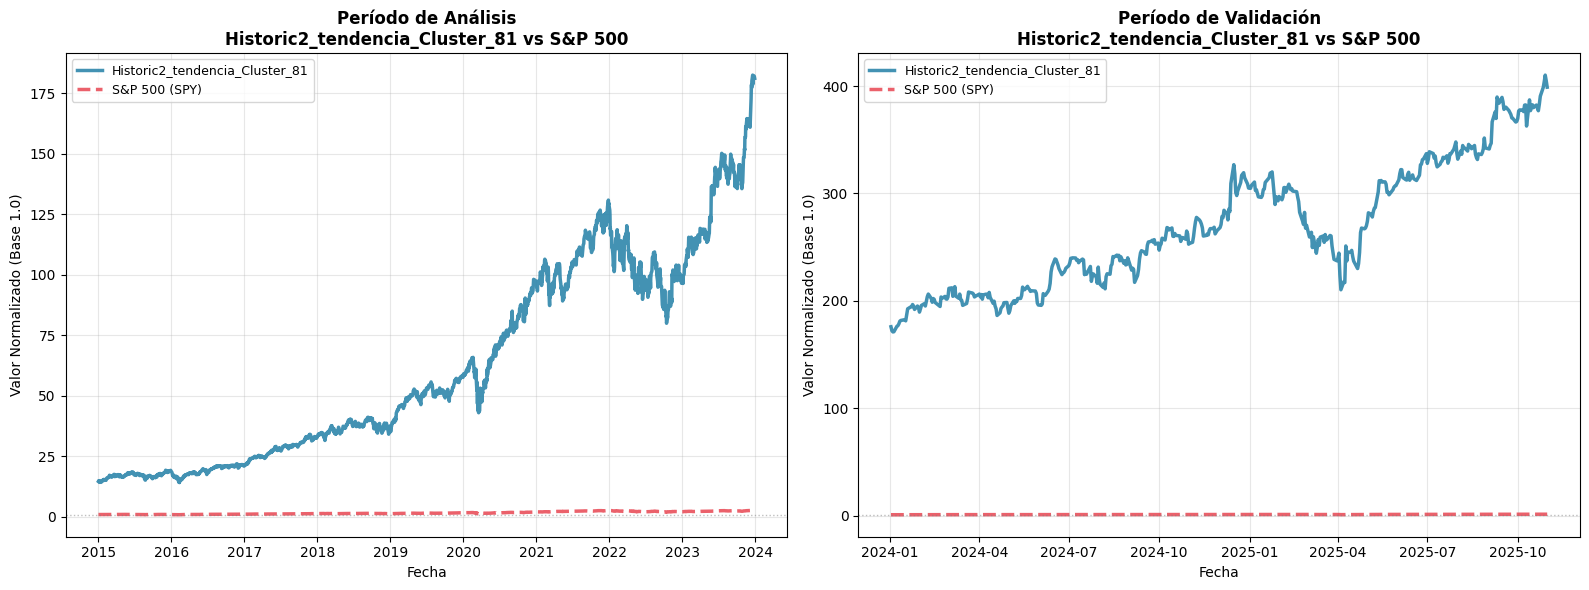


📊 GRÁFICA: DESEMPEÑO INDIVIDUAL DE TODOS LOS TICKERS DEL CLUSTER


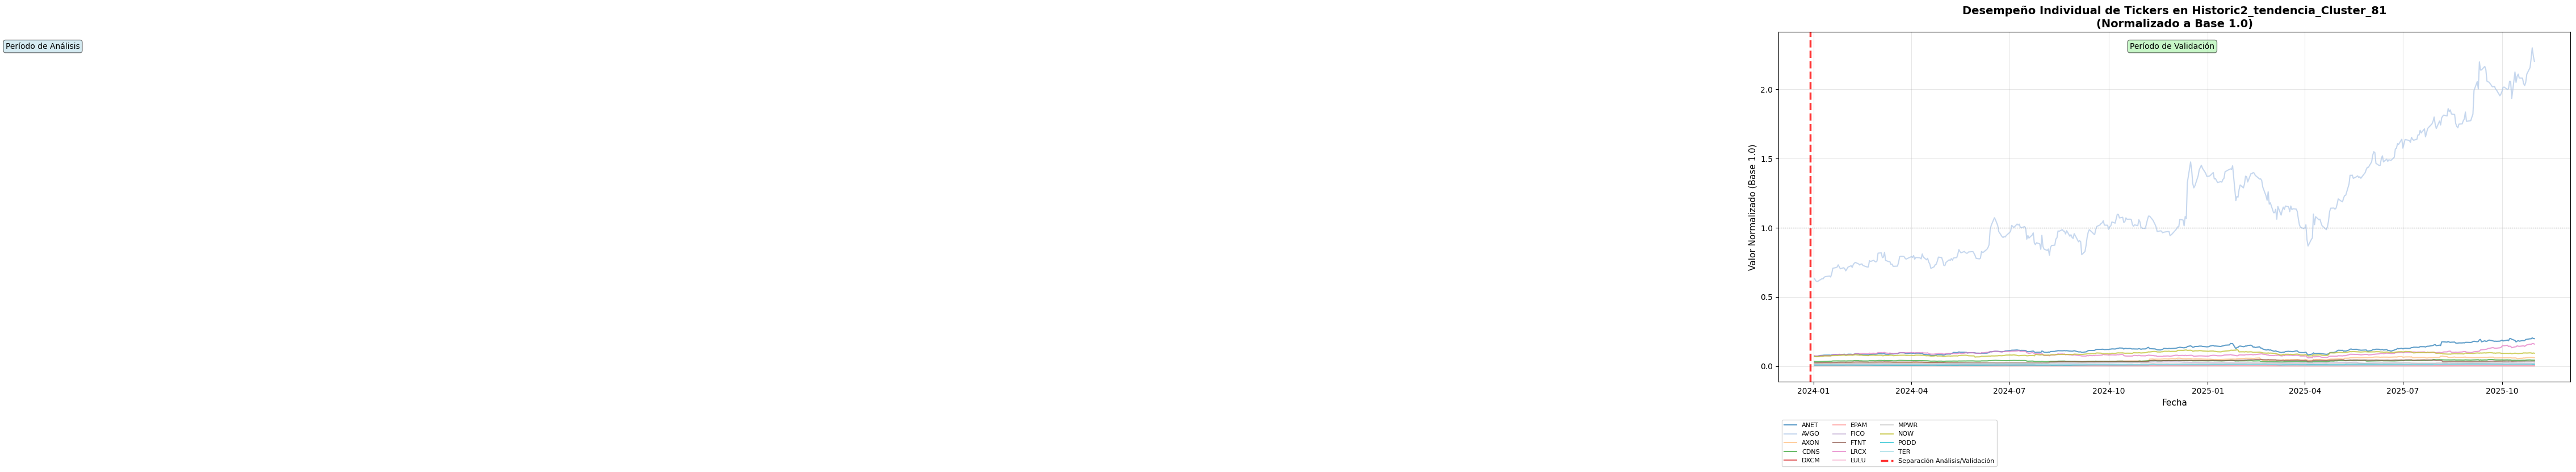

In [108]:
# Analizar un cluster específico
analizar_cluster(
    cluster_name="Historic2_tendencia_Cluster_81",
    all_clusters=all_clusters,
    tickers_data=tickers_data,
    validation_data=validation_data,
    market_caps=market_caps,
    ticker_info_db=ticker_info_db
)